In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sushantkr878/spotify-tracks-data/dataset.csv


In [2]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/sushantkr878/spotify-tracks-data/dataset.csv


# Problem Framing

## 1. Business Problem / Objective

Music streaming platforms such as Spotify contain millions of tracks across numerous genres. Correctly identifying the genre of a song is important for improving music recommendation systems, playlist generation, music organization, and user experience.

The objective of this project is to build a machine learning model capable of automatically predicting the genre of a Spotify track using its audio characteristics and metadata. By analyzing various audio features extracted from songs, the model should classify each track into its corresponding music genre.

This system can potentially assist music streaming platforms in:

* Automated music categorization
* Personalized recommendation systems
* Playlist generation
* Music discovery applications
* Audio content analysis

---

## 2. Machine Learning Problem Definition

This problem is formulated as a **Supervised Learning problem**, specifically a **Multi-Class Classification task**.

* **Problem Type:** Supervised Machine Learning
* **Task:** Classification
* **Classification Category:** Multi-Class Classification
* **Learning Approach:** Train a model using labeled examples where each song already has an associated genre.

---

## 3. Input Features (X)

The model will use the following features as predictors:

### Numerical Audio Features

* popularity
* duration_ms
* danceability
* energy
* key
* loudness
* mode
* speechiness
* acousticness
* instrumentalness
* liveness
* valence
* tempo
* time_signature

### Additional Features

* explicit

### Metadata Features (optional depending on preprocessing)

* artists
* album_name
* track_name

---

## 4. Target Variable (Y)

The target variable is:

**track_genre**

This variable represents the musical genre associated with each Spotify track.

Examples include:

* Pop
* Rock
* Hip-Hop
* Jazz
* Classical
* Electronic
* Country
* Blues
* Metal
* R&B
* and other genres available in the dataset.

---

## 5. Input-Output Mapping

The machine learning model will learn the following mapping:

```
X = {audio features of a song}
        ↓
Machine Learning Model
        ↓
Y = Predicted Genre
```

Example:

| Danceability | Energy | Acousticness | Tempo | Valence | Output     |
| ------------ | ------ | ------------ | ----- | ------- | ---------- |
| 0.82         | 0.91   | 0.02         | 128   | 0.76    | Electronic |
| 0.31         | 0.18   | 0.92         | 72    | 0.21    | Classical  |

---

## 6. Performance Metric

Since this is a multi-class classification problem, the following evaluation metrics will be used:

### Primary Metric

* **Weighted F1-Score**

### Secondary Metrics

* Accuracy
* Precision
* Recall
* Macro F1-Score
* Confusion Matrix

The Weighted F1-Score is chosen as the primary metric because the dataset contains multiple genres, and some genres may have more samples than others.

---

## 7. Assumptions

The following assumptions are made:

* The audio features provided by Spotify accurately represent the musical characteristics of each track.
* Each song belongs primarily to one genre.
* The training data is representative of unseen Spotify tracks.
* Audio features contain sufficient information to distinguish between genres.

---

## 8. Constraints

Potential constraints of this project include:

* Some genres may be highly imbalanced.
* Different genres may share similar audio characteristics.
* Songs can naturally belong to multiple genres, while the dataset provides only one label.
* Metadata features such as artist names may introduce bias.

---

## 9. Success Criteria

The project will be considered successful if the developed model:

* Achieves a high Weighted F1-Score on the test set.
* Correctly classifies the majority of music genres.
* Generalizes well to unseen tracks.
* Provides reliable predictions that could be used in recommendation or music categorization systems.

---

## 10. Proposed Machine Learning Pipeline

The planned workflow for this project is:

1. Problem Framing
2. Data Collection and Understanding
3. Exploratory Data Analysis (EDA)
4. Data Cleaning and Preprocessing
5. Feature Engineering
6. Train-Test Split
7. Model Selection
8. Model Training
9. Hyperparameter Tuning
10. Model Evaluation
11. Error Analysis

---

## Final Problem Statement

**Given the audio characteristics and metadata of a Spotify track, build a supervised machine learning model that can accurately predict the track's genre among the available music genres using a multi-class classification approach.**


# Problem Framing Summary

| Component                    | Description                                                                                                                                    |
| ---------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------- |
| **Business Problem**         | Automatically classify Spotify tracks into their correct music genres using audio features.                                                    |
| **Machine Learning Problem** | Supervised Multi-Class Classification                                                                                                          |
| **Target Variable**          | `track_genre`                                                                                                                                  |
| **Input Features**           | Audio features such as danceability, energy, loudness, speechiness, acousticness, instrumentalness, valence, tempo, popularity, etc.           |
| **Number of Classes**        | Approximately 125 music genres                                                                                                                 |
| **Evaluation Metrics**       | Primary: Weighted F1-Score; Secondary: Accuracy, Macro F1-Score, Precision, Recall, Confusion Matrix                                           |
| **Baseline Model**           | Majority class prediction and Random Classifier baseline                                                                                       |
| **Success Criteria**         | Achieve significantly higher performance than the baseline model and obtain a strong Weighted F1-Score on unseen data                          |
| **Business Application**     | Music recommendation systems, playlist generation, music discovery, and automatic music categorization                                         |
| **Expected Challenges**      | Class imbalance, overlapping genres, noisy labels, and high similarity among certain genres                                                    |
| **Cost of Error**            | Misclassification may reduce recommendation quality and user satisfaction; however, there is no direct monetary loss available in this dataset |
| **Assumptions**              | Spotify audio features adequately represent musical characteristics and are sufficient for genre prediction                                    |


# Step 2. Get the Data

In [3]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
from scipy import stats

In [4]:
df = pd.read_csv('/kaggle/input/datasets/sushantkr878/spotify-tracks-data/dataset.csv')

# Step 3. Initial Eda

In [5]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [6]:
df.tail()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
113995,113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.235,...,-16.393,1,0.0422,0.640,0.928,0.0863,0.0339,125.995,5,world-music
113996,113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.117,...,-18.318,0,0.0401,0.994,0.976,0.1050,0.0350,85.239,4,world-music
113997,113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.329,...,-10.895,0,0.0420,0.867,0.000,0.0839,0.7430,132.378,4,world-music
113998,113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.506,...,-10.889,1,0.0297,0.381,0.000,0.2700,0.4130,135.960,4,world-music
113999,113999,2hETkH7cOfqmz3LqZDHZf5,Cesária Evora,Miss Perfumado,Barbincor,22,241826,False,0.526,0.487,...,-10.204,0,0.0725,0.681,0.000,0.0893,0.7080,79.198,4,world-music


In [7]:
df.shape

(114000, 21)

In [8]:
df.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')

In [9]:
df.dtypes

Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [11]:
# missing value

In [12]:
df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [13]:
(df.isnull().sum()/len(df)*100).sort_values(ascending=False)

artists             0.000877
track_name          0.000877
album_name          0.000877
Unnamed: 0          0.000000
track_id            0.000000
popularity          0.000000
duration_ms         0.000000
explicit            0.000000
danceability        0.000000
energy              0.000000
key                 0.000000
loudness            0.000000
mode                0.000000
speechiness         0.000000
acousticness        0.000000
instrumentalness    0.000000
liveness            0.000000
valence             0.000000
tempo               0.000000
time_signature      0.000000
track_genre         0.000000
dtype: float64

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df[df.duplicated()]

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre


In [16]:
df.drop(columns='Unnamed: 0', inplace=True)

In [17]:
df.drop(columns='track_id', inplace=True)

In [18]:
df.duplicated().sum()

np.int64(577)

After removing the `Unnamed: 0` column, 450 exact duplicate records were identified. The `Unnamed: 0` column acted as a unique row identifier, masking the presence of duplicate observations. Since these records contain identical feature values and target labels, they are considered data quality duplicates and will be removed prior to model development.


In [19]:
# Statistical summary

In [20]:
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [21]:
df.describe(include="object")

,artists,album_name,track_name,track_genre
count,113999,113999,113999,114000
unique,31437,46589,73608,114
top,The Beatles,Alternative Christmas 2022,Run Rudolph Run,acoustic
freq,279,195,151,1000


In [22]:
df.describe(include='all')

,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
count,113999,113999,113999,114000.000000,1.140000e+05,114000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000
unique,31437,46589,73608,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,114
top,The Beatles,Alternative Christmas 2022,Run Rudolph Run,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,acoustic
freq,279,195,151,NaN,NaN,104253,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1000
mean,NaN,NaN,NaN,33.238535,2.280292e+05,NaN,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035,NaN
std,NaN,NaN,NaN,22.305078,1.072977e+05,NaN,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621,NaN
min,NaN,NaN,NaN,0.000000,0.000000e+00,NaN,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,NaN,NaN,NaN,17.000000,1.740660e+05,NaN,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000,NaN
50%,NaN,NaN,NaN,35.000000,2.129060e+05,NaN,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000,NaN
75%,NaN,NaN,NaN,50.000000,2.615060e+05,NaN,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000,NaN


In [23]:
# Unique values in each column

In [24]:
df.nunique().sort_values()

explicit                2
mode                    2
time_signature          5
key                    12
popularity            101
track_genre           114
danceability         1174
speechiness          1489
liveness             1722
valence              1790
energy               2083
acousticness         5061
instrumentalness     5346
loudness            19480
artists             31437
tempo               45653
album_name          46589
duration_ms         50697
track_name          73608
dtype: int64

In [25]:
# Constant and low variance features

In [26]:
# from sklearn.feature_selection import VarianceThreshold

# X = df.select_dtypes(include=['int64','float64'])

# selector = VarianceThreshold(threshold=0)
# selector.fit(X)

# print("Removed:")
# print(X.columns[~selector.get_support()])

# print("\nKept:")
# print(X.columns[selector.get_support()])

In [27]:
# from sklearn.feature_selection import VarianceThreshold

# # Select numeric columns only
# X = df.select_dtypes(include=['int64', 'float64', 'bool'])

# # Near-zero variance threshold
# selector = VarianceThreshold(threshold=0.01)

# selector.fit(X)

# # Columns with near-zero variance
# low_variance_cols = X.columns[~selector.get_support()]

# print("Near-zero variance columns:")
# print(list(low_variance_cols))

# # Show their variances
# variances = X.var()
# print("\nVariances:")
# print(variances[low_variance_cols])

In [28]:
# # Check if one value dominates a column (>99%)
# threshold = 0.99

# for col in df.columns:
#     top_freq = df[col].value_counts(normalize=True, dropna=False).iloc[0]
    
#     if top_freq > threshold:
#         print(f"{col}: {top_freq:.2%} of rows have the same value")

In [29]:
# Class distribution

In [30]:
df['track_genre'].value_counts(dropna = False)

track_genre
acoustic       1000
afrobeat       1000
alt-rock       1000
alternative    1000
ambient        1000
               ... 
techno         1000
trance         1000
trip-hop       1000
turkish        1000
world-music    1000
Name: count, Length: 114, dtype: int64

In [31]:
df['track_genre'].value_counts(normalize=True)*100

track_genre
acoustic       0.877193
afrobeat       0.877193
alt-rock       0.877193
alternative    0.877193
ambient        0.877193
                 ...   
techno         0.877193
trance         0.877193
trip-hop       0.877193
turkish        0.877193
world-music    0.877193
Name: proportion, Length: 114, dtype: float64

In [32]:
# Correlation among numerical features

In [33]:
# corr = df.select_dtypes(include=['int64','float64']).corr()
# corr

In [34]:
# Check skewness

In [35]:
num_cols = df.select_dtypes(include='number').columns
df[num_cols].skew().sort_values()

time_signature      -4.098317
loudness            -2.006542
energy              -0.597001
mode                -0.572300
danceability        -0.399497
key                 -0.008500
popularity           0.046403
valence              0.115078
tempo                0.232295
acousticness         0.727295
instrumentalness     1.734406
liveness             2.105738
speechiness          4.647516
duration_ms         11.195181
dtype: float64

In [36]:
# Check outliers quickly

In [37]:
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df[num_cols] < (Q1 - 1.5*IQR)) |
            (df[num_cols] > (Q3 + 1.5*IQR))).sum()

print(outliers.sort_values(ascending=False))

instrumentalness    25246
speechiness         13211
time_signature      12157
liveness             8642
loudness             6173
duration_ms          5617
danceability          620
tempo                 617
popularity              2
energy                  0
key                     0
mode                    0
acousticness            0
valence                 0
dtype: int64


In [38]:
# Cardinality of categorical features

In [39]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns

for col in cat_cols:
    print(f"{col}: {df[col].nunique()}")

artists: 31437
album_name: 46589
track_name: 73608
track_genre: 114


In [40]:
cat_cols

Index(['artists', 'album_name', 'track_name', 'track_genre'], dtype='object')

For your Spotify dataset, pay special attention to:
Unnamed: 0 → likely an index column, probably drop it.
track_id → unique identifier, not useful for training.
artists → very high cardinality.
album_name → very high cardinality.
track_name → very high cardinality.
track_genre → target variable.
Duplicate songs.
Class imbalance in genres.
Correlation between audio features.
Outliers in tempo, loudness, duration_ms, and popularity.

In [41]:
# df.hist(figsize=(15,10))
# plt.show()

In [42]:
# plt.figure(figsize=(15, 10))

# for i, col in enumerate(cat_cols):
#     plt.subplot(2, 2, i+1)

#     order = df[col].value_counts().index

#     sns.countplot(
#         x=df[col],
#         order=order
#     )

#     plt.title(
#         f"{col}\nUnique categories = {df[col].nunique()}"
#     )

# plt.tight_layout()
# plt.show()

In [43]:
# plt.figure(figsize=(30, 30))

# for i, col in enumerate(num_cols):
#     plt.subplot(3, 3, i+1)

#     sns.histplot(df[col], kde=True)

#     plt.title(
#         f"{col}\nSkewness = {df[col].skew():.2f}"
#     )

# plt.tight_layout()
# plt.show()

In [44]:
# from sklearn.feature_selection import VarianceThreshold

# # Select numeric columns only
# X = df.select_dtypes(include=['int64', 'float64', 'bool'])

# # Near-zero variance threshold
# selector = VarianceThreshold(threshold=0.01)

# selector.fit(X)

# # Columns with near-zero variance
# low_variance_cols = X.columns[~selector.get_support()]

# print("Near-zero variance columns:")
# print(list(low_variance_cols))

# # Show their variances
# variances = X.var()
# print("\nVariances:")
# print(variances[low_variance_cols])

### Target variable Analysis

In [45]:
df['track_genre'].value_counts(dropna=False)

track_genre
acoustic       1000
afrobeat       1000
alt-rock       1000
alternative    1000
ambient        1000
               ... 
techno         1000
trance         1000
trip-hop       1000
turkish        1000
world-music    1000
Name: count, Length: 114, dtype: int64

In [46]:
# Number of unique classes
n_classes = df['track_genre'].nunique()

print(f"Number of classes: {n_classes}")

Number of classes: 114


In [47]:
# Count of each class
target_counts = df['track_genre'].value_counts()

print(target_counts)

track_genre
acoustic       1000
afrobeat       1000
alt-rock       1000
alternative    1000
ambient        1000
               ... 
techno         1000
trance         1000
trip-hop       1000
turkish        1000
world-music    1000
Name: count, Length: 114, dtype: int64


In [48]:
# Percentage distribution
target_percent = df['track_genre'].value_counts(normalize=True) * 100

print(target_percent)

track_genre
acoustic       0.877193
afrobeat       0.877193
alt-rock       0.877193
alternative    0.877193
ambient        0.877193
                 ...   
techno         0.877193
trance         0.877193
trip-hop       0.877193
turkish        0.877193
world-music    0.877193
Name: proportion, Length: 114, dtype: float64


In [49]:
counts = df['track_genre'].value_counts()

print("Minimum samples:", counts.min())
print("Maximum samples:", counts.max())
print("Ratio:", round(counts.max()/counts.min(),2))

Minimum samples: 1000
Maximum samples: 1000
Ratio: 1.0


In [50]:
target_analysis = pd.DataFrame({
    'Count': df['track_genre'].value_counts(),
    'Percentage': round(
        df['track_genre'].value_counts(normalize=True)*100, 2
    )
})

print(target_analysis)

             Count  Percentage
track_genre                   
acoustic      1000        0.88
afrobeat      1000        0.88
alt-rock      1000        0.88
alternative   1000        0.88
ambient       1000        0.88
...            ...         ...
techno        1000        0.88
trance        1000        0.88
trip-hop      1000        0.88
turkish       1000        0.88
world-music   1000        0.88

[114 rows x 2 columns]


In [51]:
# df['track_genre'].value_counts().plot(kind='bar',
#                                       figsize=(20,6))

# plt.title('Target Variable Distribution')
# plt.xlabel('Genre')
# plt.ylabel('Count')
# plt.show()

In [52]:
counts = df['track_genre'].value_counts()

if counts.max() == counts.min():
    print("Target variable is perfectly balanced.")
else:
    print("Target variable is imbalanced.")

Target variable is perfectly balanced.


In [53]:
# plt.figure(figsize=(25,6))

# sns.countplot(
#     x='track_genre',
#     data=df,
#     order=df['track_genre'].value_counts().index
# )

# plt.title('Distribution of Track Genres')
# plt.xlabel('Track Genre')
# plt.ylabel('Count')
# plt.xticks(rotation=90)

# plt.show()

In [54]:
# plt.figure(figsize=(15,5))

# sns.countplot(
#     x='track_genre',
#     data=df,
#     order=df['track_genre'].value_counts().index
# )

# plt.xticks([], [])  # hide genre names
# plt.title('Target Variable Distribution (114 Classes)')
# plt.ylabel('Count')

# plt.show()

In [55]:
df.duplicated().sum()

np.int64(577)

# Train Test Split

In [56]:
X = df.drop('track_genre' , axis = 1)
y = df['track_genre']

In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,stratify=y)

In [58]:
X_train.shape

(91200, 18)

In [59]:
X_test.shape

(22800, 18)

# Detailed EDA on Train Data Only

In [60]:
# total 21 steps 

In [61]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(91200, 18)
(22800, 18)
(91200,)
(22800,)


In [62]:
y_train.value_counts(normalize=True)

track_genre
metal        0.008772
party        0.008772
pop-film     0.008772
funk         0.008772
dubstep      0.008772
               ...   
piano        0.008772
indie        0.008772
disney       0.008772
groove       0.008772
metalcore    0.008772
Name: proportion, Length: 114, dtype: float64

In [63]:
y_test.value_counts(normalize=True)

track_genre
kids              0.008772
gospel            0.008772
dance             0.008772
jazz              0.008772
minimal-techno    0.008772
                    ...   
idm               0.008772
study             0.008772
metal             0.008772
pop-film          0.008772
samba             0.008772
Name: proportion, Length: 114, dtype: float64

In [64]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 91200 entries, 71066 to 8176
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   artists           91199 non-null  object 
 1   album_name        91199 non-null  object 
 2   track_name        91199 non-null  object 
 3   popularity        91200 non-null  int64  
 4   duration_ms       91200 non-null  int64  
 5   explicit          91200 non-null  bool   
 6   danceability      91200 non-null  float64
 7   energy            91200 non-null  float64
 8   key               91200 non-null  int64  
 9   loudness          91200 non-null  float64
 10  mode              91200 non-null  int64  
 11  speechiness       91200 non-null  float64
 12  acousticness      91200 non-null  float64
 13  instrumentalness  91200 non-null  float64
 14  liveness          91200 non-null  float64
 15  valence           91200 non-null  float64
 16  tempo             91200 non-null  float64


In [65]:
X_train.head()

,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
71066,Evanescence,Twisted Halloween Hits,Bring Me To Life,0,235893,False,0.318,0.943,4,-3.188,0,0.1070,0.00721,0.000002,0.2420,0.298,189.985,4
71918,Poets of the Fall,Signs of Life,Lift,47,313360,False,0.483,0.872,11,-5.088,1,0.0383,0.01710,0.001310,0.0851,0.733,153.986,4
78491,Matthias Reim,Déjà Vu - Das Beste Von Matthias Reim,Jedes Bild von dir,31,237026,False,0.565,0.662,4,-6.636,0,0.0265,0.11800,0.000000,0.1270,0.358,130.058,4
80730,Ghibran;Sid Sriram,"Yaar Azhaippadhu (From ""Maara"")","Yaar Azhaippadhu - From ""Maara""",57,250325,False,0.626,0.525,10,-7.417,1,0.0338,0.67500,0.000000,0.0645,0.450,114.921,3
37740,Menor MC,Trap Funk Star,Idolatria,44,142495,False,0.731,0.301,8,-15.436,0,0.5460,0.25000,0.000000,0.1190,0.568,127.933,4


In [66]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 91200 entries, 71066 to 8176
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   artists           91199 non-null  object 
 1   album_name        91199 non-null  object 
 2   track_name        91199 non-null  object 
 3   popularity        91200 non-null  int64  
 4   duration_ms       91200 non-null  int64  
 5   explicit          91200 non-null  bool   
 6   danceability      91200 non-null  float64
 7   energy            91200 non-null  float64
 8   key               91200 non-null  int64  
 9   loudness          91200 non-null  float64
 10  mode              91200 non-null  int64  
 11  speechiness       91200 non-null  float64
 12  acousticness      91200 non-null  float64
 13  instrumentalness  91200 non-null  float64
 14  liveness          91200 non-null  float64
 15  valence           91200 non-null  float64
 16  tempo             91200 non-null  float64


In [67]:
num_cols = X_train.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

In [68]:
print("Numerical Columns:")
print(num_cols)

Numerical Columns:
['popularity', 'duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']


In [69]:
# Categorical columns
cat_cols = X_train.select_dtypes(
    include=['object', 'bool']
).columns.tolist()

In [70]:
print("\nCategorical Columns:")
print(cat_cols)


Categorical Columns:
['artists', 'album_name', 'track_name', 'explicit']


In [71]:
print(f"Number of numerical columns: {len(num_cols)}")

Number of numerical columns: 14


In [72]:
print(f"Number of categorical columns: {len(cat_cols)}")

Number of categorical columns: 4


In [73]:
# X_train[num_cols].describe().T

In [74]:
# num_summary = X_train[num_cols].describe().T

# num_summary['range'] = (
#     num_summary['max'] - num_summary['min']
# )

# num_summary['IQR'] = (
#     num_summary['75%'] - num_summary['25%']
# )

# num_summary

In [75]:
X_train['explicit'].describe()

count     91200
unique        2
top       False
freq      83395
Name: explicit, dtype: object

In [76]:
summary = pd.DataFrame({
    'dtype': X_train.dtypes,
    'missing': X_train.isnull().sum(),
    'unique': X_train.nunique()
}).T

summary

,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
dtype,object,object,object,int64,int64,bool,float64,float64,int64,float64,int64,float64,float64,float64,float64,float64,float64,int64
missing,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
unique,27831,40649,62012,101,44314,2,1142,1990,12,18277,2,1466,4942,5304,1708,1767,40262,5


In [77]:
X_train[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
popularity,91200.0,33.173191,22.289220,0.000,17.00000,34.000000,50.0000,100.000
duration_ms,91200.0,227931.089101,108137.822117,0.000,174000.00000,212800.000000,261345.2500,5237295.000
danceability,91200.0,0.566777,0.173621,0.000,0.45600,0.580000,0.6950,0.985
energy,91200.0,0.641615,0.251448,0.000,0.47200,0.685000,0.8540,1.000
key,91200.0,5.305011,3.558433,0.000,2.00000,5.000000,8.0000,11.000
loudness,91200.0,-8.251478,5.022584,-49.531,-10.00200,-6.994000,-5.0040,2.574
mode,91200.0,0.638399,0.480467,0.000,0.00000,1.000000,1.0000,1.000
speechiness,91200.0,0.084541,0.105505,0.000,0.03590,0.048900,0.0843,0.963
acousticness,91200.0,0.314981,0.332383,0.000,0.01680,0.169000,0.5980,0.996
instrumentalness,91200.0,0.155834,0.309260,0.000,0.00000,0.000041,0.0490,1.000


In [78]:
X_train[cat_cols].describe().T

,count,unique,top,freq
artists,91199,27831,The Beatles,221
album_name,91199,40649,Alternative Christmas 2022,156
track_name,91199,62012,Run Rudolph Run,108
explicit,91200,2,False,83395


1.  duration_ms has a very wide range, indicating possible outliers.
2.  popularity spans from 0 to 100.
3.  tempo exhibits high variability.
4.  artists, album_name, and track_name have extremely high cardinality.
5.  mode and time_signature have low cardinality.
6.  No obvious impossible values were observed.

  <!-- Step 5: Missing Value Analysis
Why are we doing this?

To answer these questions:

Which columns have missing values?
How many values are missing?
What percentage is missing?
Is the missingness small, moderate, or severe?
What strategy should we use later (drop, mean, median, mode, etc.)? -->

In [79]:
# Step 5: Missing Value Analysis
# Why are we doing this?

# To answer these questions:

# Which columns have missing values?
# How many values are missing?
# What percentage is missing?
# Is the missingness small, moderate, or severe?
# What strategy should we use later (drop, mean, median, mode, etc.)?

In [80]:
X_train.isnull().sum()

artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
dtype: int64

In [81]:
# Missing value percentage
(X_train.isnull().sum() / len(X_train) * 100).sort_values(ascending=False)

artists             0.001096
album_name          0.001096
track_name          0.001096
popularity          0.000000
duration_ms         0.000000
explicit            0.000000
danceability        0.000000
energy              0.000000
key                 0.000000
loudness            0.000000
mode                0.000000
speechiness         0.000000
acousticness        0.000000
instrumentalness    0.000000
liveness            0.000000
valence             0.000000
tempo               0.000000
time_signature      0.000000
dtype: float64

In [82]:
# Professional summary table
missing_df = pd.DataFrame({
    'Missing_Count': X_train.isnull().sum(),
    'Missing_Percentage':
        round(X_train.isnull().sum() / len(X_train) * 100, 2)
})

missing_df = missing_df[
    missing_df['Missing_Count'] > 0
].sort_values(
    by='Missing_Percentage',
    ascending=False
)

missing_df

,Missing_Count,Missing_Percentage
artists,1,0.0
album_name,1,0.0
track_name,1,0.0


In [83]:
# # Visualize missing values
# plt.figure(figsize=(12,5))

# sns.heatmap(
#     X_train.isnull(),
#     cbar=False,
#     yticklabels=False
# )

# plt.title("Missing Values Heatmap")
# plt.show()

In [84]:
# Count rows having at least one missing value
(X_train.isnull().sum(axis=1) > 0).sum()

np.int64(1)

In [85]:
# Missing values by column
for col in X_train.columns:
    miss = X_train[col].isnull().sum()

    if miss > 0:
        print(
            f"{col}: "
            f"{miss} "
            f"({miss/len(X_train)*100:.2f}%)"
        )

artists: 1 (0.00%)
album_name: 1 (0.00%)
track_name: 1 (0.00%)


1. artists      : Mode imputation
2. album_name   : Mode imputation
3. track_name   : Mode imputation

In [86]:
# NOw lets find why this data is missing , what is the cause behind it ? 

In [87]:
# # Step 1: Check whether missingness is random 
# df['artists_missing'] = df['artists'].isnull().astype(int)

In [88]:
# # compare with other variables.
# pd.crosstab(
#     df['album_name'],
#     df['artists_missing']
# )

In [89]:
# 1. Check for MCAR (Little's MCAR Test)

In [90]:
# pip install pyampute

In [91]:
# # 1. Check for MCAR (Little's MCAR Test)
# from pyampute.exploration.mcar_statistical_tests import MCARTest

# # Create a copy
# X_mcar = X_train.copy()

# # Convert object columns to categorical codes
# for col in ['artists', 'album_name', 'track_name']:
#     X_mcar[col] = X_mcar[col].astype('category').cat.codes

# # Keep only numeric columns
# X_mcar = X_mcar.select_dtypes(
#     include=['int64', 'float64', 'bool']
# )

# # Run Little's MCAR test
# mcar = MCARTest()

# p_value = mcar.little_mcar_test(X_mcar)

# print("P-value:", p_value)

# if p_value > 0.05:
#     print("Data may be MCAR")
# else:
#     print("Data is NOT MCAR")

In [92]:
# TEST GOT FAILED 

In [93]:
# # Learn it in small data 
# from pyampute.exploration.mcar_statistical_tests import MCARTest

# # Create sample data
# df = pd.DataFrame({
#     'age': [23,25,np.nan,30,40,np.nan,35,28,45,50],
#     'salary': [50000,np.nan,60000,70000,np.nan,80000,75000,68000,90000,np.nan],
#     'experience': [1,2,3,np.nan,5,6,7,8,np.nan,10]
# })

# mcar = MCARTest()

# p = mcar.little_mcar_test(df)

# print("P-value:", p)

# if p > 0.05:
#     print("Data may be MCAR")
# else:
#     print("Data is NOT MCAR")

Little's MCAR test produced a p-value of 0.0205, which is below the significance level of 0.05. Therefore, the null hypothesis that the data are Missing Completely At Random (MCAR) is rejected. This indicates that the missingness pattern is not entirely random and may depend on observed or unobserved factors. Further investigation is required to determine whether the missingness mechanism is MAR or MNAR.


Little's MCAR test can only tell you "MCAR or not MCAR." It cannot distinguish between MAR and MNAR.

In [94]:
# The missing values are likely MCAR due to data collection/scraping issues; 
# formal testing is unnecessary because the amount of missingness is negligible (<0.001%).

In [95]:
# 2. Check for MAR

In [96]:
# #  Create a missing indicator:
# X_train['artists_missing'] = (
#     X_train['artists']
#     .isnull()
#     .astype(int)
# )

In [97]:
# # Now check whether missingness depends on other variables:
# sns.boxplot(
#     x='artists_missing',
#     y='popularity',
#     data=X_train
# )

# plt.show()

In [98]:
# pd.crosstab(
#     X_train['explicit'],
#     X_train['artists_missing']
# )

In [99]:
# The artists column contains only one missing value, which is insufficient to determine whether the missingness mechanism is MAR or MNAR. 
#The missing value is most likely due to random data collection
#or scraping issues and can reasonably be treated as MCAR.

In [100]:
# 3. Check for MNAR

# There is no statistical test for MNAR.

# For THis Spotify dataset

# have:

# artists
# album_name
# track_name

# with only one missing value each.

# The professional conclusion is:

# Most likely MCAR
# because the missing values are extremely few and probably caused by data collection/scraping issues.

In [101]:
# FInal conclusion is this data is MCAR

The columns `artists`, `album_name`, and `track_name` each contain only one missing value.
Due to the extremely low proportion of missing data, a formal investigation of the missingness 
mechanism (MCAR, MAR, or MNAR) is not meaningful. These missing values are most likely caused 
by data collection or scraping issues and are therefore assumed to be Missing Completely At Random (MCAR).


In [102]:
# so i will drop them 
# 1 row lost out of 91,200 is 0.001% — statistically and practically zero information loss.
# X_train = X_train.dropna(subset=['artists', 'album_name', 'track_name'])

#### Duplicate Analysis

In [103]:
# Step 6: Duplicate Analysis
# Why are we doing this?

# Duplicates can:

# bias the model,
# cause data leakage,
# artificially improve performance,
# overrepresent certain observations.

# The goal is to answer:

# Are there duplicate rows, and should we remove them?

In [104]:
X_train.duplicated().sum()

np.int64(16041)

In [105]:
dup_count = X_train.duplicated().sum()

print("Duplicate rows:", dup_count)

Duplicate rows: 16041


In [106]:
dup_percent = (
    X_train.duplicated().sum()
    / len(X_train)
) * 100

print(f"Duplicate percentage: {dup_percent:.2f}%")

Duplicate percentage: 17.59%


In [107]:
duplicates = X_train[
    X_train.duplicated()
]

duplicates.head()

,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
49147,De Doelleazen,Skijt Oan De Rest,Skijt Oan De Rest,32,161428,False,0.684,0.963,11,-3.463,0,0.0498,0.1320,0.000013,0.1740,0.509,167.934,4
51985,Don Omar;Sharlene Taule,Para entrar en calor,Encanto,1,195400,False,0.744,0.871,8,-5.123,1,0.0499,0.1450,0.000498,0.0752,0.902,172.030,4
93387,Vladimir Nechaev,Velikie ispolniteli Rossii XX veka: Vladimir N...,"Okh, neprijatnost'",0,183072,False,0.334,0.357,9,-10.103,0,0.0305,0.9840,0.002600,0.3180,0.585,149.913,4
99032,Suzonn,Sun Lo Na (Raw),Sun Lo Na (Raw),55,174466,False,0.856,0.178,1,-15.241,1,0.0464,0.7480,0.005930,0.0937,0.632,130.089,3
88252,Jhayco;Bad Bunny,Bájale como 7500,CÓMO SE SIENTE - Remix,0,227520,True,0.807,0.606,3,-8.871,0,0.0872,0.0946,0.000000,0.1190,0.304,92.988,4


In [108]:
X_train[
    X_train.duplicated(
        keep=False
    )
].sort_values(
    by=X_train.columns.tolist()
)

,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
63488,10-FEET,VANDALIZE,SHOES,34,137893,False,0.517,0.981,9,-1.222,1,0.1100,0.069000,0.000000,0.0610,0.654,124.821,4
100702,10-FEET,VANDALIZE,SHOES,34,137893,False,0.517,0.981,9,-1.222,1,0.1100,0.069000,0.000000,0.0610,0.654,124.821,4
99694,10cc,Fiesta temática 70s,Art For Art's Sake,0,359235,False,0.616,0.570,0,-7.797,1,0.0517,0.058100,0.001420,0.2250,0.622,124.721,4
8319,10cc,Fiesta temática 70s,Art For Art's Sake,0,359235,False,0.616,0.570,0,-7.797,1,0.0517,0.058100,0.001420,0.2250,0.622,124.721,4
102694,10cc,Fiesta temática 70s,Art For Art's Sake,0,359235,False,0.616,0.570,0,-7.797,1,0.0517,0.058100,0.001420,0.2250,0.622,124.721,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12507,張德蘭,情若無花不結果,情若無花不結果,23,216413,False,0.468,0.229,9,-12.936,0,0.0303,0.823000,0.000000,0.1830,0.362,79.102,4
12288,李炳文,關不掉的聲音,昨夜的渡輪上,25,220840,False,0.554,0.345,6,-10.199,0,0.0268,0.749000,0.000000,0.1100,0.168,107.625,4
70580,李炳文,關不掉的聲音,昨夜的渡輪上,25,220840,False,0.554,0.345,6,-10.199,0,0.0268,0.749000,0.000000,0.1100,0.168,107.625,4
72502,花冷え。,NEET GAME,NEET GAME,52,169500,False,0.492,0.974,1,-3.913,1,0.1050,0.000025,0.000028,0.0646,0.192,100.946,4


In [109]:
duplicates = df[
    df.duplicated(
        keep=False
    )
]

duplicates.head(20)

,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
1874,Buena Onda Reggae Club,Disco 2,Song for Rollins,16,219346,False,0.841,0.577,0,-7.544,1,0.0438,0.23800,0.860000,0.0571,0.843,90.522,4,afrobeat
1925,Buena Onda Reggae Club,Disco 2,Song for Rollins,16,219346,False,0.841,0.577,0,-7.544,1,0.0438,0.23800,0.860000,0.0571,0.843,90.522,4,afrobeat
2044,The Killers;Ryan Pardey,Alternative Christmas 2022,Don't Shoot Me Santa,0,245106,False,0.588,0.847,8,-4.164,1,0.0705,0.06010,0.000000,0.3070,0.662,120.041,4,alt-rock
2046,The Killers;Ryan Pardey,Alternative Christmas 2022,Don't Shoot Me Santa,0,245106,False,0.588,0.847,8,-4.164,1,0.0705,0.06010,0.000000,0.3070,0.662,120.041,4,alt-rock
2082,The Smashing Pumpkins,Alternative Christmas 2022,Christmastime,0,196723,False,0.165,0.434,0,-8.163,1,0.0288,0.31600,0.171000,0.2130,0.186,77.983,3,alt-rock
2085,The Smashing Pumpkins,Alternative Christmas 2022,Christmastime,0,196723,False,0.165,0.434,0,-8.163,1,0.0288,0.31600,0.171000,0.2130,0.186,77.983,3,alt-rock
2093,Weezer,Alternative Christmas 2022,We Wish You A Merry Christmas,0,84973,False,0.387,0.786,11,-4.127,1,0.0436,0.01950,0.000000,0.1230,0.462,149.806,3,alt-rock
2094,Weezer,Alternative Christmas 2022,We Wish You A Merry Christmas,0,84973,False,0.387,0.786,11,-4.127,1,0.0436,0.01950,0.000000,0.1230,0.462,149.806,3,alt-rock
2109,Red Hot Chili Peppers,Stadium Arcadium,Snow (Hey Oh),80,334666,False,0.427,0.900,11,-3.674,1,0.0499,0.11600,0.000017,0.1190,0.599,104.655,4,alt-rock
2116,Counting Crows,Alternative Christmas 2022,A Long December,0,297293,False,0.403,0.590,5,-5.941,1,0.0284,0.50800,0.005480,0.2720,0.393,141.649,4,alt-rock


Inspection of duplicated observations revealed the presence of exact duplicate records, where all feature values and the target variable were identical. These duplicates are likely due to data collection or dataset construction issues rather than representing distinct observations. Since exact duplicates can introduce bias and overrepresent certain samples, they will be removed prior to model training.


In [110]:
# df = df.drop_duplicates()

1. Now X_train.duplicated() checks duplicates using only the 19 feature columns.

2. This means your dataset contains many rows like:

3. track_id 	artists    ...	track_genre
4. A123	       Artist X    ...	pop
5. A123	       Artist X	   ...	rock

During duplicate analysis, no duplicate records were initially detected because the dataset contained the `Unnamed: 0` column, which acted as a unique row identifier. After removing this column, 450 exact duplicate records were identified, indicating that these duplicates had been masked by the index column.

Subsequently, after separating the target variable (`track_genre`) from the feature set, the number of duplicate observations in the training features increased to 15,982. This occurred because many records share identical feature values but belong to different genres. Therefore, these observations are not duplicates in the original dataset but become duplicate feature vectors once the target variable is removed. This behavior is expected and does not indicate an error in the train-test split process.


A total of 450 exact duplicate records were identified after removing the `Unnamed: 0` column and were removed as data quality duplicates. The larger number of duplicate observations (15,982) observed after removing the target variable represents duplicate feature vectors belonging to different genres and does not indicate erroneous records. Therefore, these observations were retained to preserve valid information and avoid unnecessary loss of data.


1. ✅ Remove 450 exact duplicates from df.
2. ❌ Do not remove the 15,982 duplicate feature vectors from X_train.

### Step 7: Unique Values / Cardinality Analysis

To understand:

1. How many unique values each column has.
2. Whether a column is an ID column (almost all values unique).
3. Whether a categorical column has high cardinality, which may create problems during encoding.
4. Whether some columns should be dropped or handled specially.

In [111]:
#Number of unique values in each column
X_train.nunique().sort_values(ascending=False)

track_name          62012
duration_ms         44314
album_name          40649
tempo               40262
artists             27831
loudness            18277
instrumentalness     5304
acousticness         4942
energy               1990
valence              1767
liveness             1708
speechiness          1466
danceability         1142
popularity            101
key                    12
time_signature          5
explicit                2
mode                    2
dtype: int64

In [112]:
# Unique percentage of each column
unique_percent = (
    X_train.nunique() / len(X_train)
) * 100

unique_percent.sort_values(ascending=False)

track_name          67.995614
duration_ms         48.589912
album_name          44.571272
tempo               44.146930
artists             30.516447
loudness            20.040570
instrumentalness     5.815789
acousticness         5.418860
energy               2.182018
valence              1.937500
liveness             1.872807
speechiness          1.607456
danceability         1.252193
popularity           0.110746
key                  0.013158
time_signature       0.005482
explicit             0.002193
mode                 0.002193
dtype: float64

In [113]:
# Create a summary table
cardinality = pd.DataFrame({
    'dtype': X_train.dtypes,
    'n_unique': X_train.nunique(),
    'unique_%': (X_train.nunique()/len(X_train))*100
})

cardinality.sort_values(
    by='n_unique',
    ascending=False
)

,dtype,n_unique,unique_%
track_name,object,62012,67.995614
duration_ms,int64,44314,48.589912
album_name,object,40649,44.571272
tempo,float64,40262,44.146930
artists,object,27831,30.516447
loudness,float64,18277,20.040570
instrumentalness,float64,5304,5.815789
acousticness,float64,4942,5.418860
energy,float64,1990,2.182018
valence,float64,1767,1.937500


In [114]:
# Inspect high-cardinality categorical columns
cat_cols = X_train.select_dtypes(
    include=['object']
).columns

for col in cat_cols:
    print(f"\n{col}")
    print("Unique values:", X_train[col].nunique())


artists
Unique values: 27831

album_name
Unique values: 40649

track_name
Unique values: 62012


In [115]:
# Check whether a column behaves like an ID
for col in X_train.columns:
    ratio = X_train[col].nunique() / len(X_train)

    if ratio > 0.95:
        print(col, "→ Possible ID column")

In [116]:
cardinality.sort_values('n_unique', ascending=False).head(10)

,dtype,n_unique,unique_%
track_name,object,62012,67.995614
duration_ms,int64,44314,48.589912
album_name,object,40649,44.571272
tempo,float64,40262,44.146930
artists,object,27831,30.516447
loudness,float64,18277,20.040570
instrumentalness,float64,5304,5.815789
acousticness,float64,4942,5.418860
energy,float64,1990,2.182018
valence,float64,1767,1.937500


Cardinality analysis revealed that `track_name`, `album_name`, and `artists` are high-cardinality categorical features,  Numerical features such as `duration_ms`, `tempo`, and `loudness` exhibit high uniqueness, which is expected for continuous variables. Low-cardinality features, including `explicit`, `mode`, `time_signature`, and `key`, were retained and will be encoded appropriately during the preprocessing stage using techniques such as one-hot encoding based on their underlying characteristics.


Final note:

1. Drop: track_name, album_name, artists
2. Encode: explicit, mode, time_signature, key
3. Keep as numeric: All remaining audio features.

1. Numerical Columns → Near-Zero Variance Analysis 

❓ What are we doing?

We are checking whether any numerical feature has very little variation across observations.


    
❓ Why are we doing this?

Features with very low variance contain little information and contribute minimally to model performance. Such features can increase noise and unnecessary complexity.


In [117]:
from sklearn.feature_selection import VarianceThreshold

# Select numerical columns
num_cols = X_train.select_dtypes(
    include=['int64', 'float64', 'bool']
)

# Apply Variance Threshold
selector = VarianceThreshold(threshold=0.01)
selector.fit(num_cols)

# Columns with near-zero variance
low_variance_cols = num_cols.columns[
    ~selector.get_support()
]

print("Near-zero variance columns:")
print(list(low_variance_cols))

# Show variances
print("\nVariances:")
print(num_cols.var()[low_variance_cols])

Near-zero variance columns:
[]

Variances:
Series([], dtype: float64)


Near-zero variance analysis was performed using the `VarianceThreshold()` method with a threshold of 0.01. No features were identified as having near-zero variance, indicating that all numerical variables exhibit sufficient variability and may contribute useful information to the predictive model. Therefore, no numerical features were removed based on variance.


2. Categorical Columns → Dominant Category Analysis
❓ What are we doing?

We are checking whether a single category dominates a feature (for example, one category occupies more than 95% of the observations).

❓ Why are we doing this?

Features with highly dominant categories provide very little discriminative information and may not contribute meaningfully to prediction.

In [118]:
cat_cols = ['explicit', 'mode', 'time_signature', 'key']

for col in cat_cols:
    print(f"\n{'='*40}")
    print(f"Column: {col}")

    vc = X_train[col].value_counts(normalize=True) * 100

    print(vc)

    if vc.iloc[0] > 95:
        print("⚠ Dominant category (>95%) detected")
    else:
        print("✓ No dominant category")


Column: explicit
explicit
False    91.441886
True      8.558114
Name: proportion, dtype: float64
✓ No dominant category

Column: mode
mode
1    63.839912
0    36.160088
Name: proportion, dtype: float64
✓ No dominant category

Column: time_signature
time_signature
4    89.347588
3     8.059211
5     1.610746
1     0.839912
0     0.142544
Name: proportion, dtype: float64
✓ No dominant category

Column: key
key
7     11.680921
0     11.469298
2     10.231360
9      9.839912
1      9.438596
5      8.203947
11     8.154605
4      7.922149
6      6.958333
10     6.491228
8      6.474781
3      3.134868
Name: proportion, dtype: float64
✓ No dominant category


Dominant category analysis was performed on the low-cardinality categorical features (`explicit`, `mode`, `time_signature`, and `key`). None of the features contained a category exceeding the predefined threshold of 95%. This indicates that all categorical variables possess sufficient variation and are likely to provide meaningful information for the model. Therefore, all categorical features were retained for further analysis and encoding.


1. ✅ explicit → One-Hot Encoding (or binary encoding, since it has only 2 values)
2. ✅ mode → One-Hot Encoding (or keep as 0/1)
3. ✅ time_signature → One-Hot Encoding
4. ✅key → One-Hot Encoding

1. ✅ track_name → Drop (very high cardinality, not useful for classical ML)
2. ✅ album_name → Drop (very high cardinality)
3. ✅ artists → Drop (very high cardinality; encoding would create too many features)
4. ✅ All numerical columns (popularity, duration_ms, danceability, energy, loudness, speechiness, acousticness, 
    instrumentalness, liveness, valence, tempo) → Keep as numerical

## Step - 8 UNIVARIATE ANALYSIS - NUMERICAL FEATURES

A) Histograms + KDE
❓ What are we doing?

We are visualizing the distribution of each numerical feature.

❓ Why are we doing this?

To identify:

1. Distribution shape
2. Skewness
3. Multimodality
4. Range
5. Whether transformation is needed

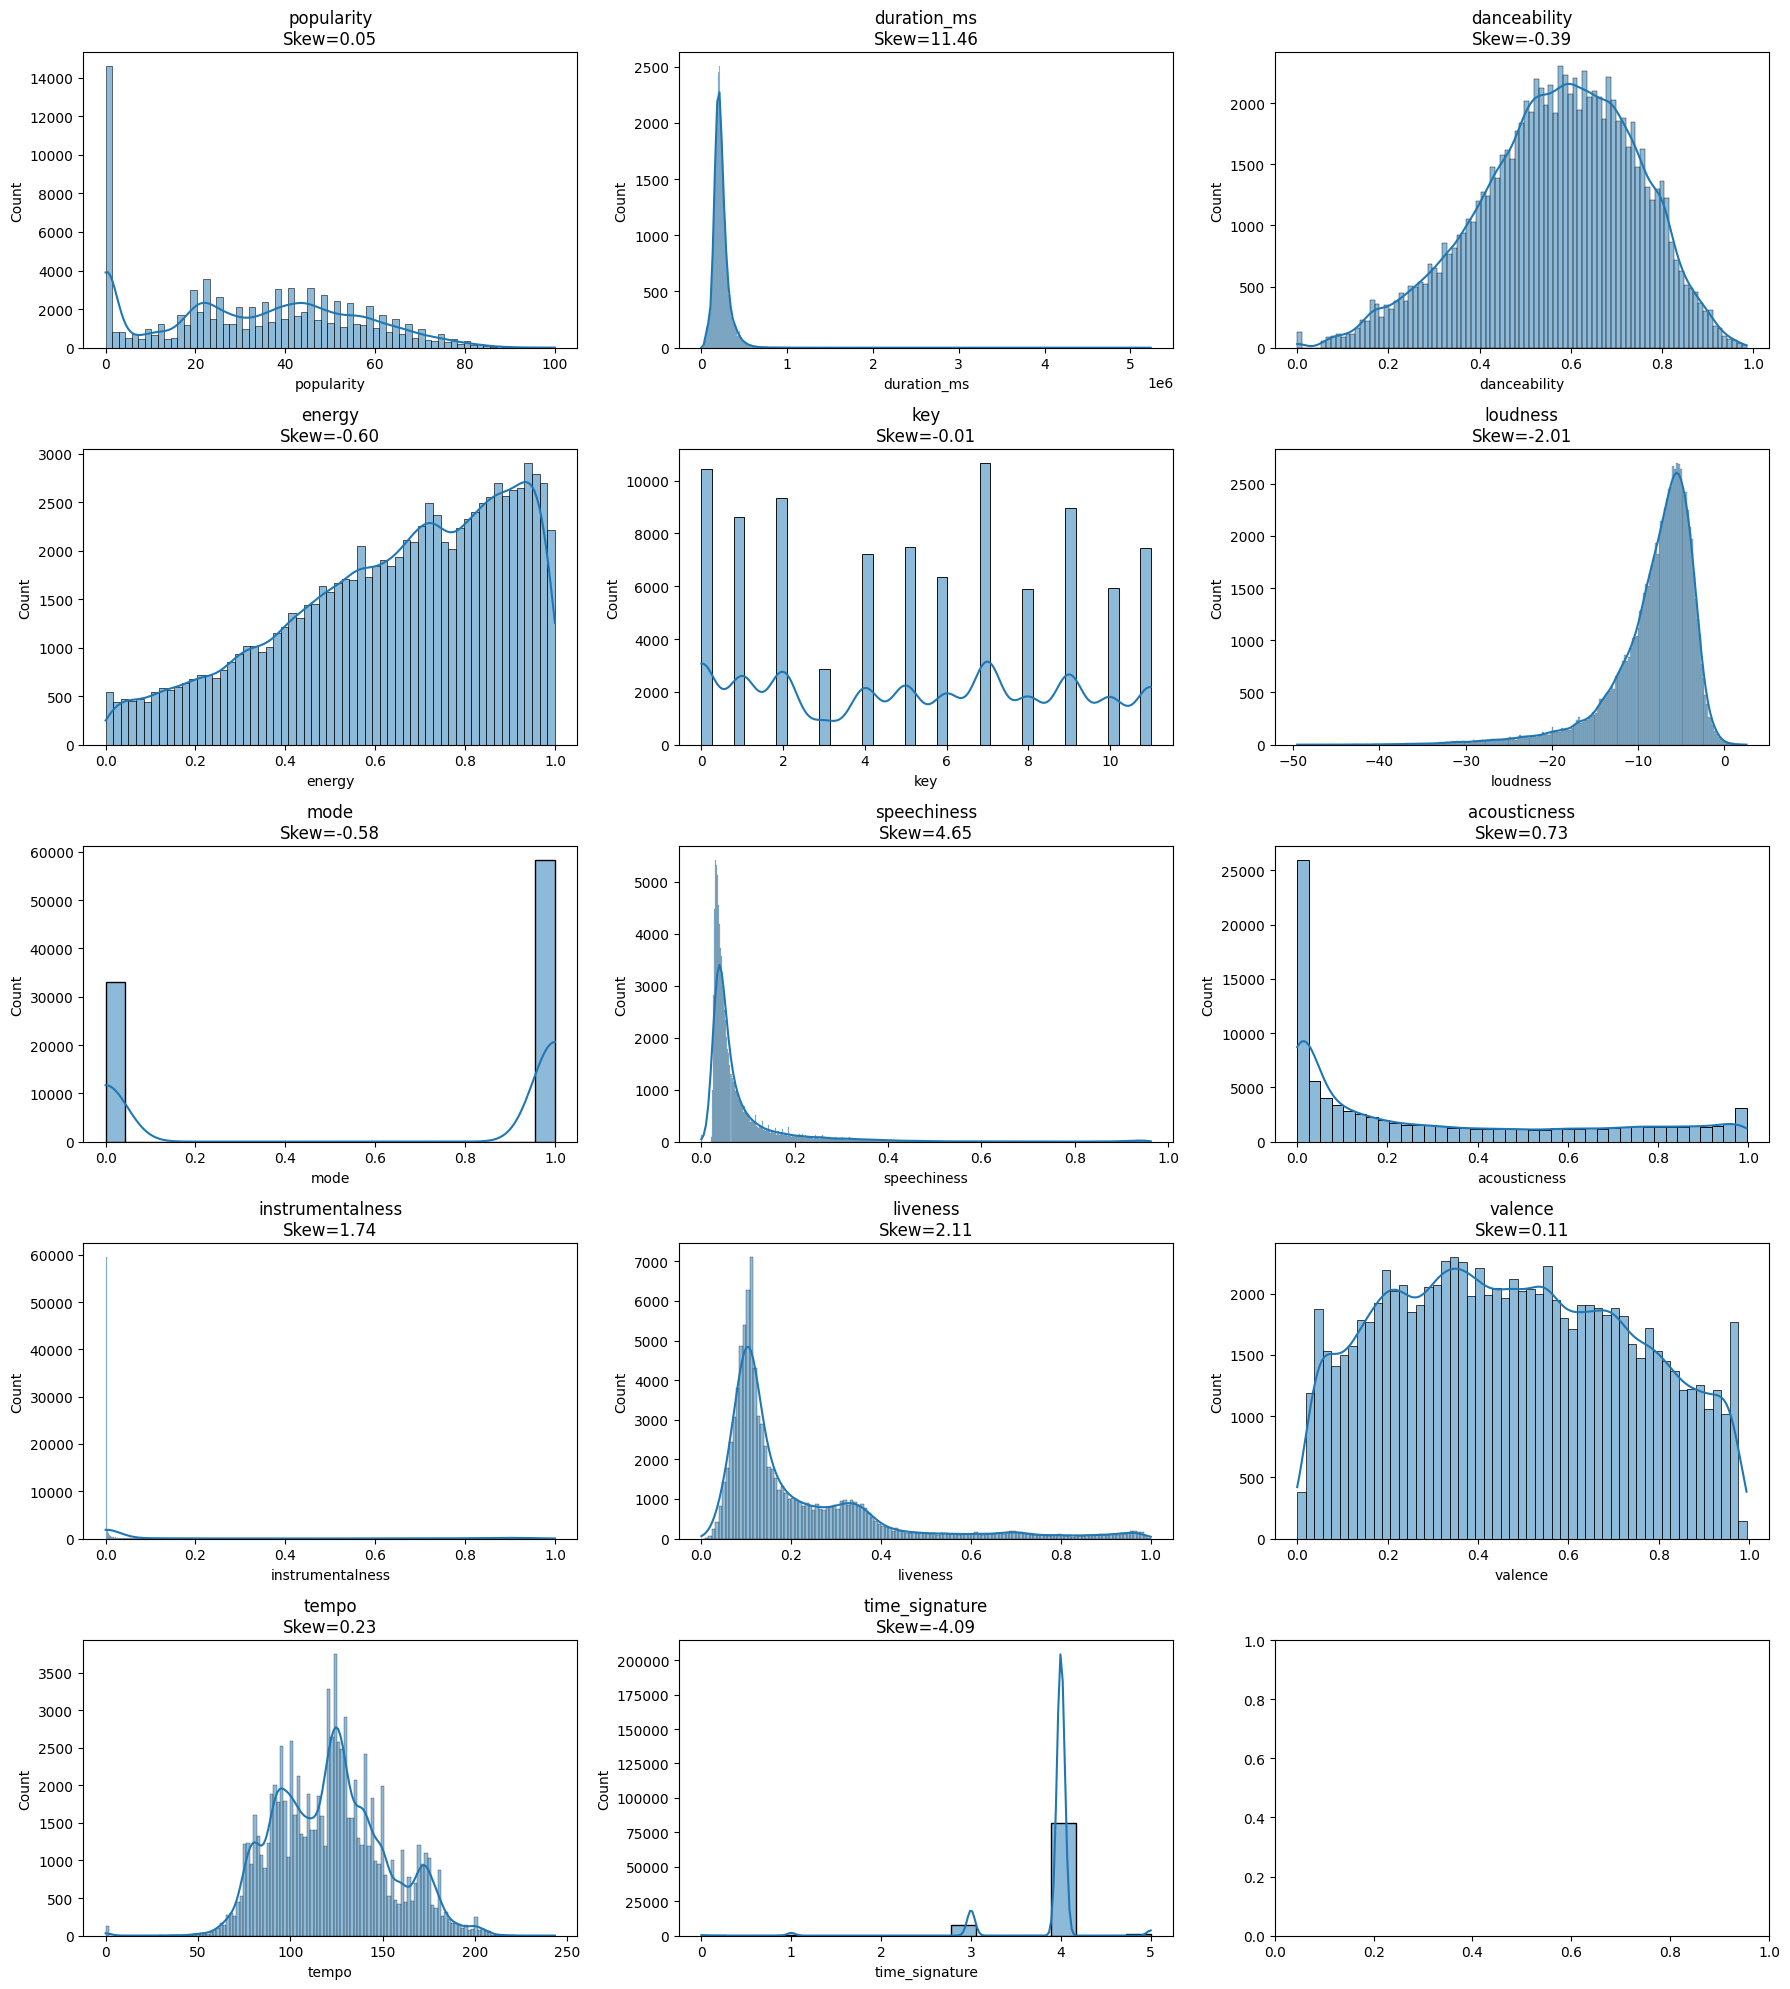

In [119]:
num_cols = X_train.select_dtypes(
    include=['int64', 'float64']
).columns

fig, axes = plt.subplots(
    nrows=(len(num_cols)+2)//3,
    ncols=3,
    figsize=(18,20)
)

axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(
        X_train[col],
        kde=True,
        ax=axes[i]
    )

    skew = X_train[col].skew()

    axes[i].set_title(
        f'{col}\nSkew={skew:.2f}'
    )

plt.tight_layout()
plt.show()

B) Skewness Analysis
❓ What are we doing?

We are measuring the asymmetry of each distribution.

❓ Why are we doing this?

To determine whether feature transformation may be required.

In [120]:
skewness = (
    X_train[num_cols]
    .skew()
    .sort_values(ascending=False)
)

print(skewness)

duration_ms         11.460887
speechiness          4.645205
liveness             2.112556
instrumentalness     1.736409
acousticness         0.726115
tempo                0.227831
valence              0.113719
popularity           0.046687
key                 -0.006810
danceability        -0.393963
mode                -0.576116
energy              -0.597463
loudness            -2.005550
time_signature      -4.093875
dtype: float64


C) Kurtosis Analysis
❓ What are we doing?

We are measuring tail heaviness.

❓ Why are we doing this?

To identify variables prone to extreme values and outliers.

In [121]:
kurtosis = (
    X_train[num_cols]
    .kurtosis()
    .sort_values(ascending=False)
)

print(kurtosis)

duration_ms         363.055354
speechiness          28.807735
time_signature       26.091648
loudness              5.887213
liveness              4.415754
instrumentalness      1.279268
tempo                -0.108399
danceability         -0.188055
energy               -0.524156
popularity           -0.931552
acousticness         -0.951418
valence              -1.025006
key                  -1.274613
mode                 -1.668127
dtype: float64


| Kurtosis  | Meaning            |
| --------- | ------------------ |
| ≈0        | Normal             |
| >3        | Heavy tails        |
| Very high | Potential outliers |


D) Boxplots
❓ What are we doing?

Visualizing the spread and outliers.

❓ Why are we doing this?

To identify potential outliers.

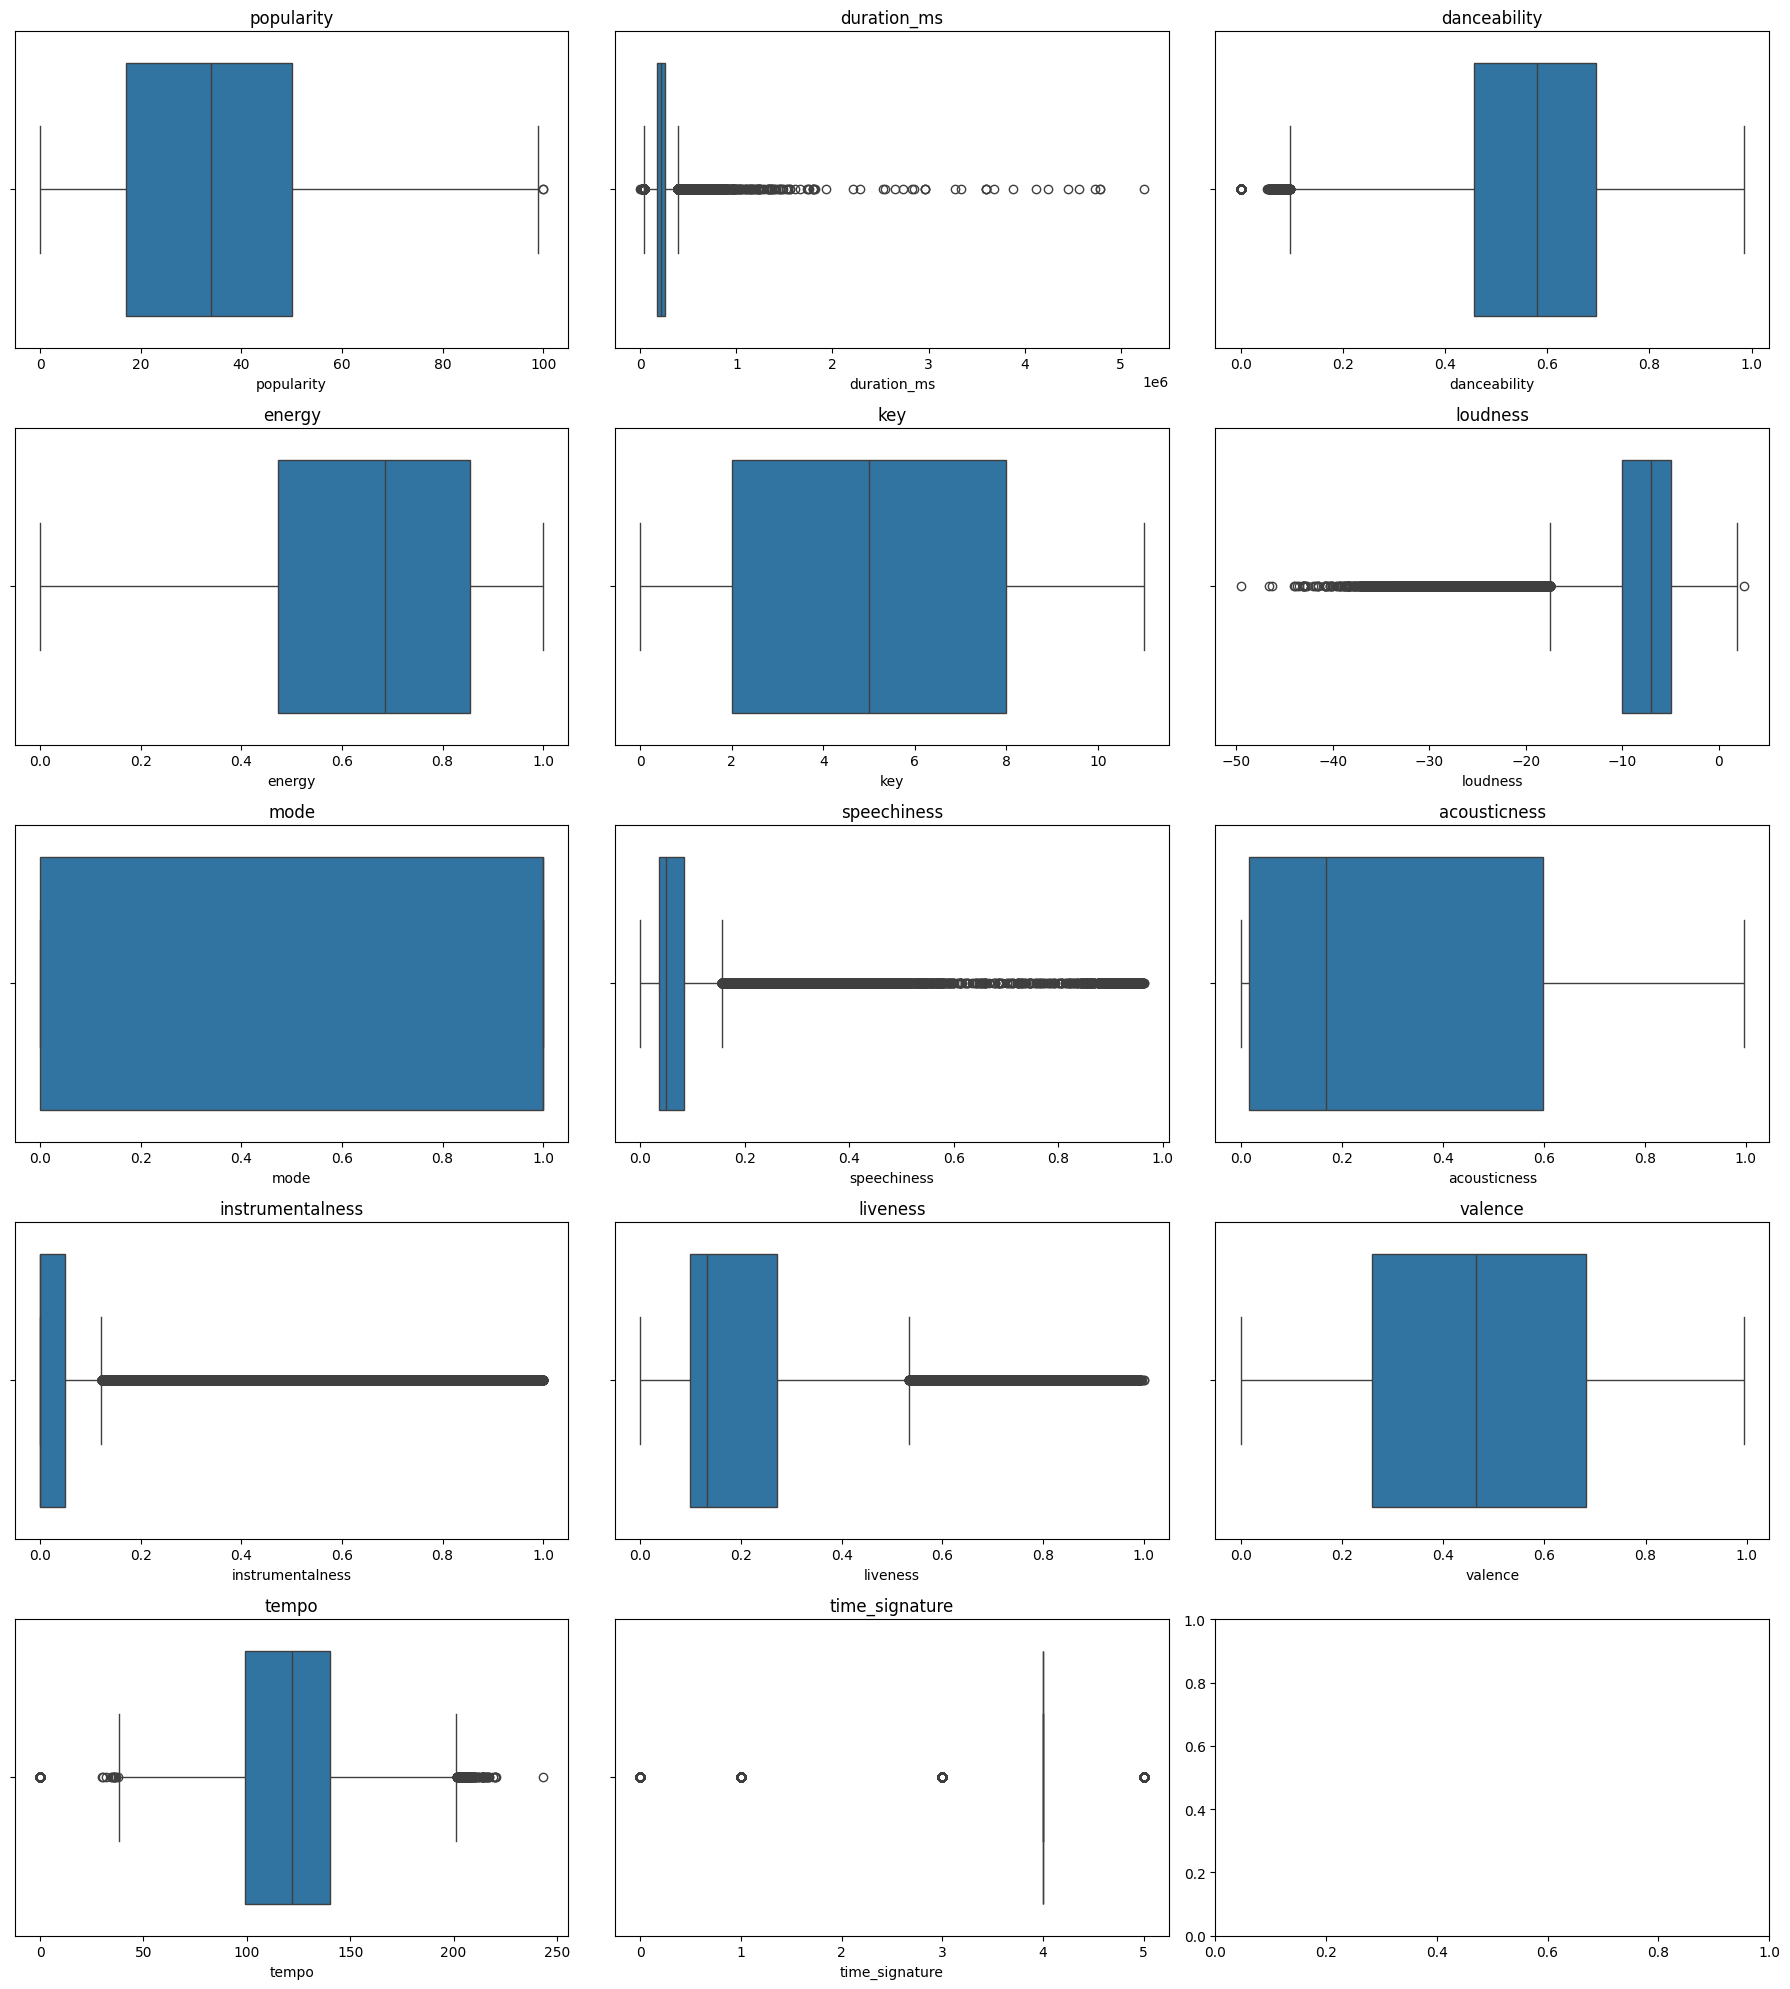

In [122]:
fig, axes = plt.subplots(
    nrows=(len(num_cols)+2)//3,
    ncols=3,
    figsize=(18,20)
)

axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(
        x=X_train[col],
        ax=axes[i]
    )

    axes[i].set_title(col)

plt.tight_layout()
plt.show()

E) Range Analysis
❓ What are we doing?

Checking minimum, maximum, and quantiles.

❓ Why are we doing this?

To identify impossible values or suspicious ranges.

In [123]:
range_analysis = pd.DataFrame({
    'min': X_train[num_cols].min(),
    'Q1': X_train[num_cols].quantile(0.25),
    'median': X_train[num_cols].median(),
    'Q3': X_train[num_cols].quantile(0.75),
    'max': X_train[num_cols].max()
})

range_analysis

,min,Q1,median,Q3,max
popularity,0.000,17.00000,34.000000,50.0000,100.000
duration_ms,0.000,174000.00000,212800.000000,261345.2500,5237295.000
danceability,0.000,0.45600,0.580000,0.6950,0.985
energy,0.000,0.47200,0.685000,0.8540,1.000
key,0.000,2.00000,5.000000,8.0000,11.000
loudness,-49.531,-10.00200,-6.994000,-5.0040,2.574
mode,0.000,0.00000,1.000000,1.0000,1.000
speechiness,0.000,0.03590,0.048900,0.0843,0.963
acousticness,0.000,0.01680,0.169000,0.5980,0.996
instrumentalness,0.000,0.00000,0.000041,0.0490,1.000


In [124]:
X_train[num_cols].skew().sort_values(ascending=False)

duration_ms         11.460887
speechiness          4.645205
liveness             2.112556
instrumentalness     1.736409
acousticness         0.726115
tempo                0.227831
valence              0.113719
popularity           0.046687
key                 -0.006810
danceability        -0.393963
mode                -0.576116
energy              -0.597463
loudness            -2.005550
time_signature      -4.093875
dtype: float64

In [125]:
X_train[num_cols].kurtosis().sort_values(ascending=False)

duration_ms         363.055354
speechiness          28.807735
time_signature       26.091648
loudness              5.887213
liveness              4.415754
instrumentalness      1.279268
tempo                -0.108399
danceability         -0.188055
energy               -0.524156
popularity           -0.931552
acousticness         -0.951418
valence              -1.025006
key                  -1.274613
mode                 -1.668127
dtype: float64

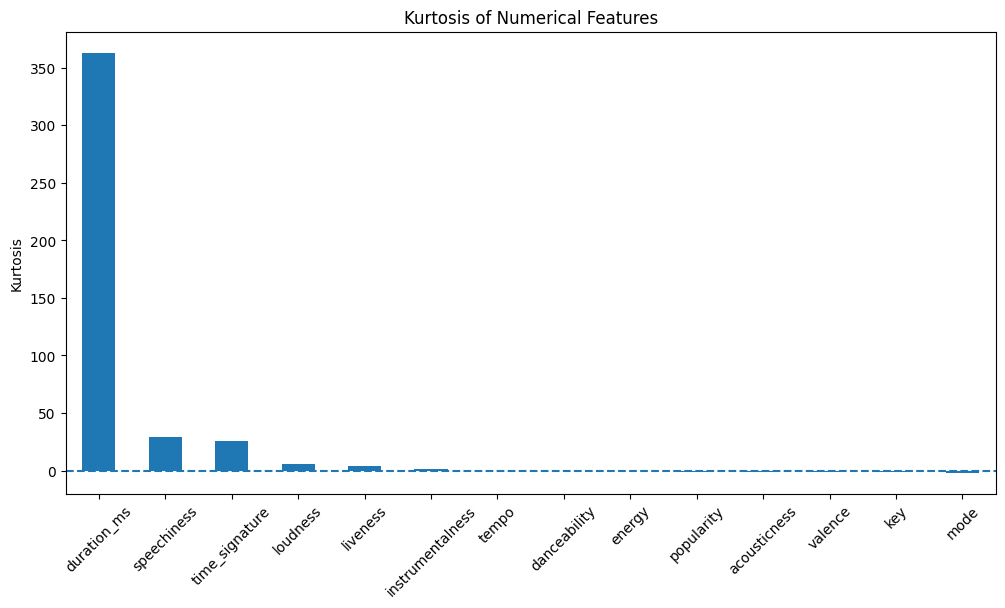

In [126]:
kurtosis = X_train[num_cols].kurtosis().sort_values(ascending=False)

plt.figure(figsize=(12,6))
kurtosis.plot(kind='bar')

plt.axhline(y=0, linestyle='--')   # Normal distribution reference

plt.title('Kurtosis of Numerical Features')
plt.ylabel('Kurtosis')
plt.xticks(rotation=45)

plt.show()

Step 9: Univariate Analysis — Categorical Features
❓ What are we doing?

We are analyzing each categorical feature individually.

❓ Why are we doing this?

To identify:

1. Dominant categories
2. Rare categories
3. Category distribution
4. Cardinality
5. Whether grouping or encoding strategies may be required

In [127]:
cat_cols = X_train.select_dtypes(
    include=['object', 'bool']
).columns

for col in cat_cols:
    print("\n" + "="*50)
    print(f"Column: {col}")
    print(X_train[col].value_counts(dropna=False))


Column: artists
artists
The Beatles                 221
George Jones                220
Stevie Wonder               185
Prateek Kuhad               175
Ella Fitzgerald             169
                           ... 
Projota;Dado Villa-Lobos      1
Sensey;Hugo Toxxx             1
JOHNNASCUS                    1
Anime;Dave Revan              1
Technimatic;Rhode             1
Name: count, Length: 27832, dtype: int64

Column: album_name
album_name
Alternative Christmas 2022     156
Feliz Cumpleaños con Perreo    150
Metal                          112
Halloween con perreito         103
Halloween Party 2022           102
                              ... 
Foco, Força E Fé                 1
Microwaved Weed                  1
Aman Iman: Water Is Life         1
SHADYXV                          1
The Twist                        1
Name: count, Length: 40650, dtype: int64

Column: track_name
track_name
Run Rudolph Run                                                           108
Halloween       

In [128]:
# 2. Percentage Distribution
for col in cat_cols:
    print("\n" + "="*50)
    print(f"Column: {col}")
    print(
        (X_train[col]
         .value_counts(normalize=True,
                       dropna=False)
         *100)
         .round(2)
    )


Column: artists
artists
The Beatles                 0.24
George Jones                0.24
Stevie Wonder               0.20
Prateek Kuhad               0.19
Ella Fitzgerald             0.19
                            ... 
Projota;Dado Villa-Lobos    0.00
Sensey;Hugo Toxxx           0.00
JOHNNASCUS                  0.00
Anime;Dave Revan            0.00
Technimatic;Rhode           0.00
Name: proportion, Length: 27832, dtype: float64

Column: album_name
album_name
Alternative Christmas 2022     0.17
Feliz Cumpleaños con Perreo    0.16
Metal                          0.12
Halloween con perreito         0.11
Halloween Party 2022           0.11
                               ... 
Foco, Força E Fé               0.00
Microwaved Weed                0.00
Aman Iman: Water Is Life       0.00
SHADYXV                        0.00
The Twist                      0.00
Name: proportion, Length: 40650, dtype: float64

Column: track_name
track_name
Run Rudolph Run                                           

In [129]:
# # 3. Countplots

# for col in cat_cols:
#     plt.figure(figsize=(8,4))

#     sns.countplot(
#         x=X_train[col]
#     )

#     plt.title(col)
#     plt.xticks(rotation=45)

#     plt.show()

| Check               | Meaning                                 |
| ------------------- | --------------------------------------- |
| Dominant categories | One category occupies most observations |
| Rare categories     | Very few observations                   |
| Cardinality         | Number of unique categories             |
| Missing values      | Hidden NaNs                             |
| Encoding strategy   | OHE, binary, drop, etc.                 |


1. track_name → Very high cardinality → Drop
2. album_name → Very high cardinality → Drop
3. artists → Very high cardinality → Drop
4. explicit → Binary → Keep
5. mode → Binary → Keep
6. time_signature → Low cardinality → One-Hot Encode
7. key → Low cardinality → One-Hot Encode

# Step 9: Outlier Analysis
❓ What are we doing?

We are identifying and quantifying extreme values in numerical features.

❓ Why are we doing this?

To determine:

1. Which features contain outliers
2. How many outliers exist
3. Whether outlier treatment is required
4. Which outlier handling method to apply later

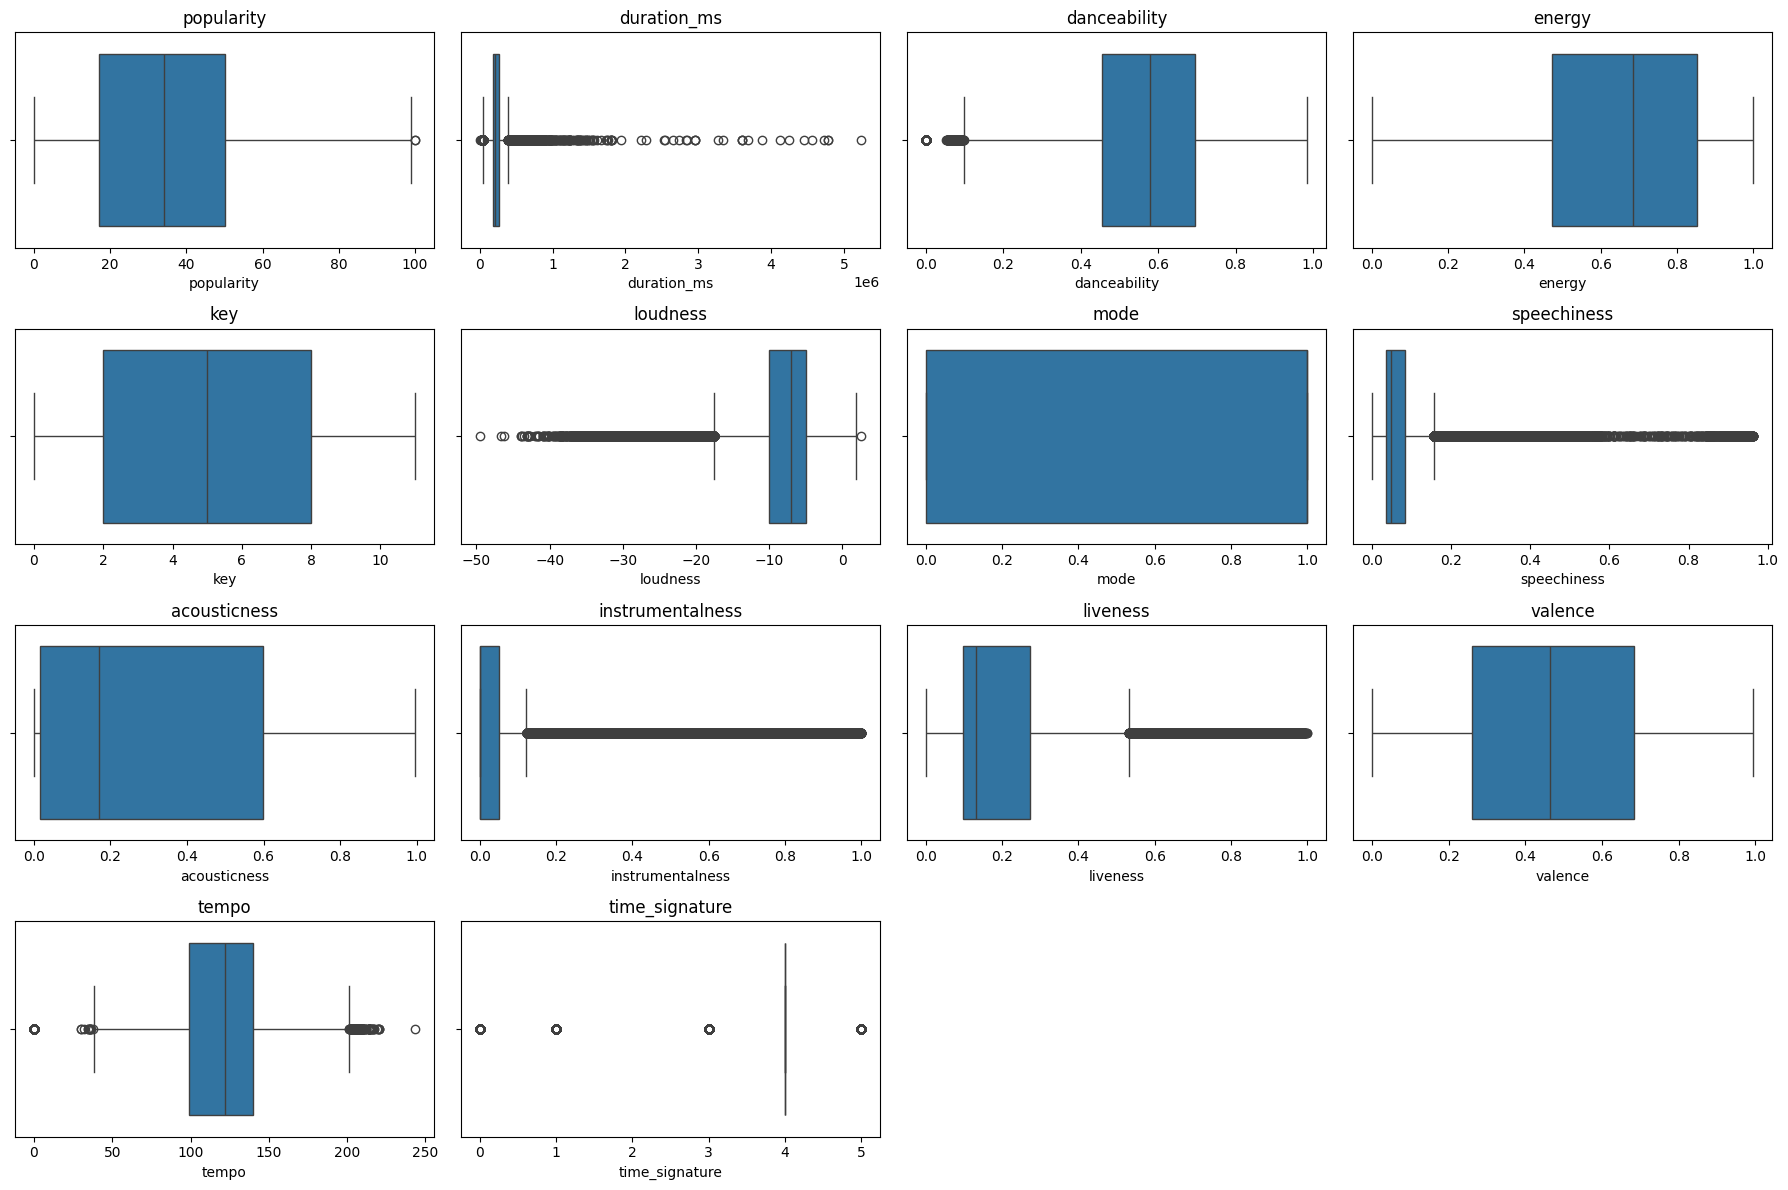

In [130]:
# 1. Visual Outlier Detection (Boxplots)

plt.figure(figsize=(18,12))

for i, col in enumerate(num_cols, 1):
    plt.subplot(4,4,i)
    sns.boxplot(x=X_train[col])
    plt.title(col)

plt.tight_layout()
plt.show()

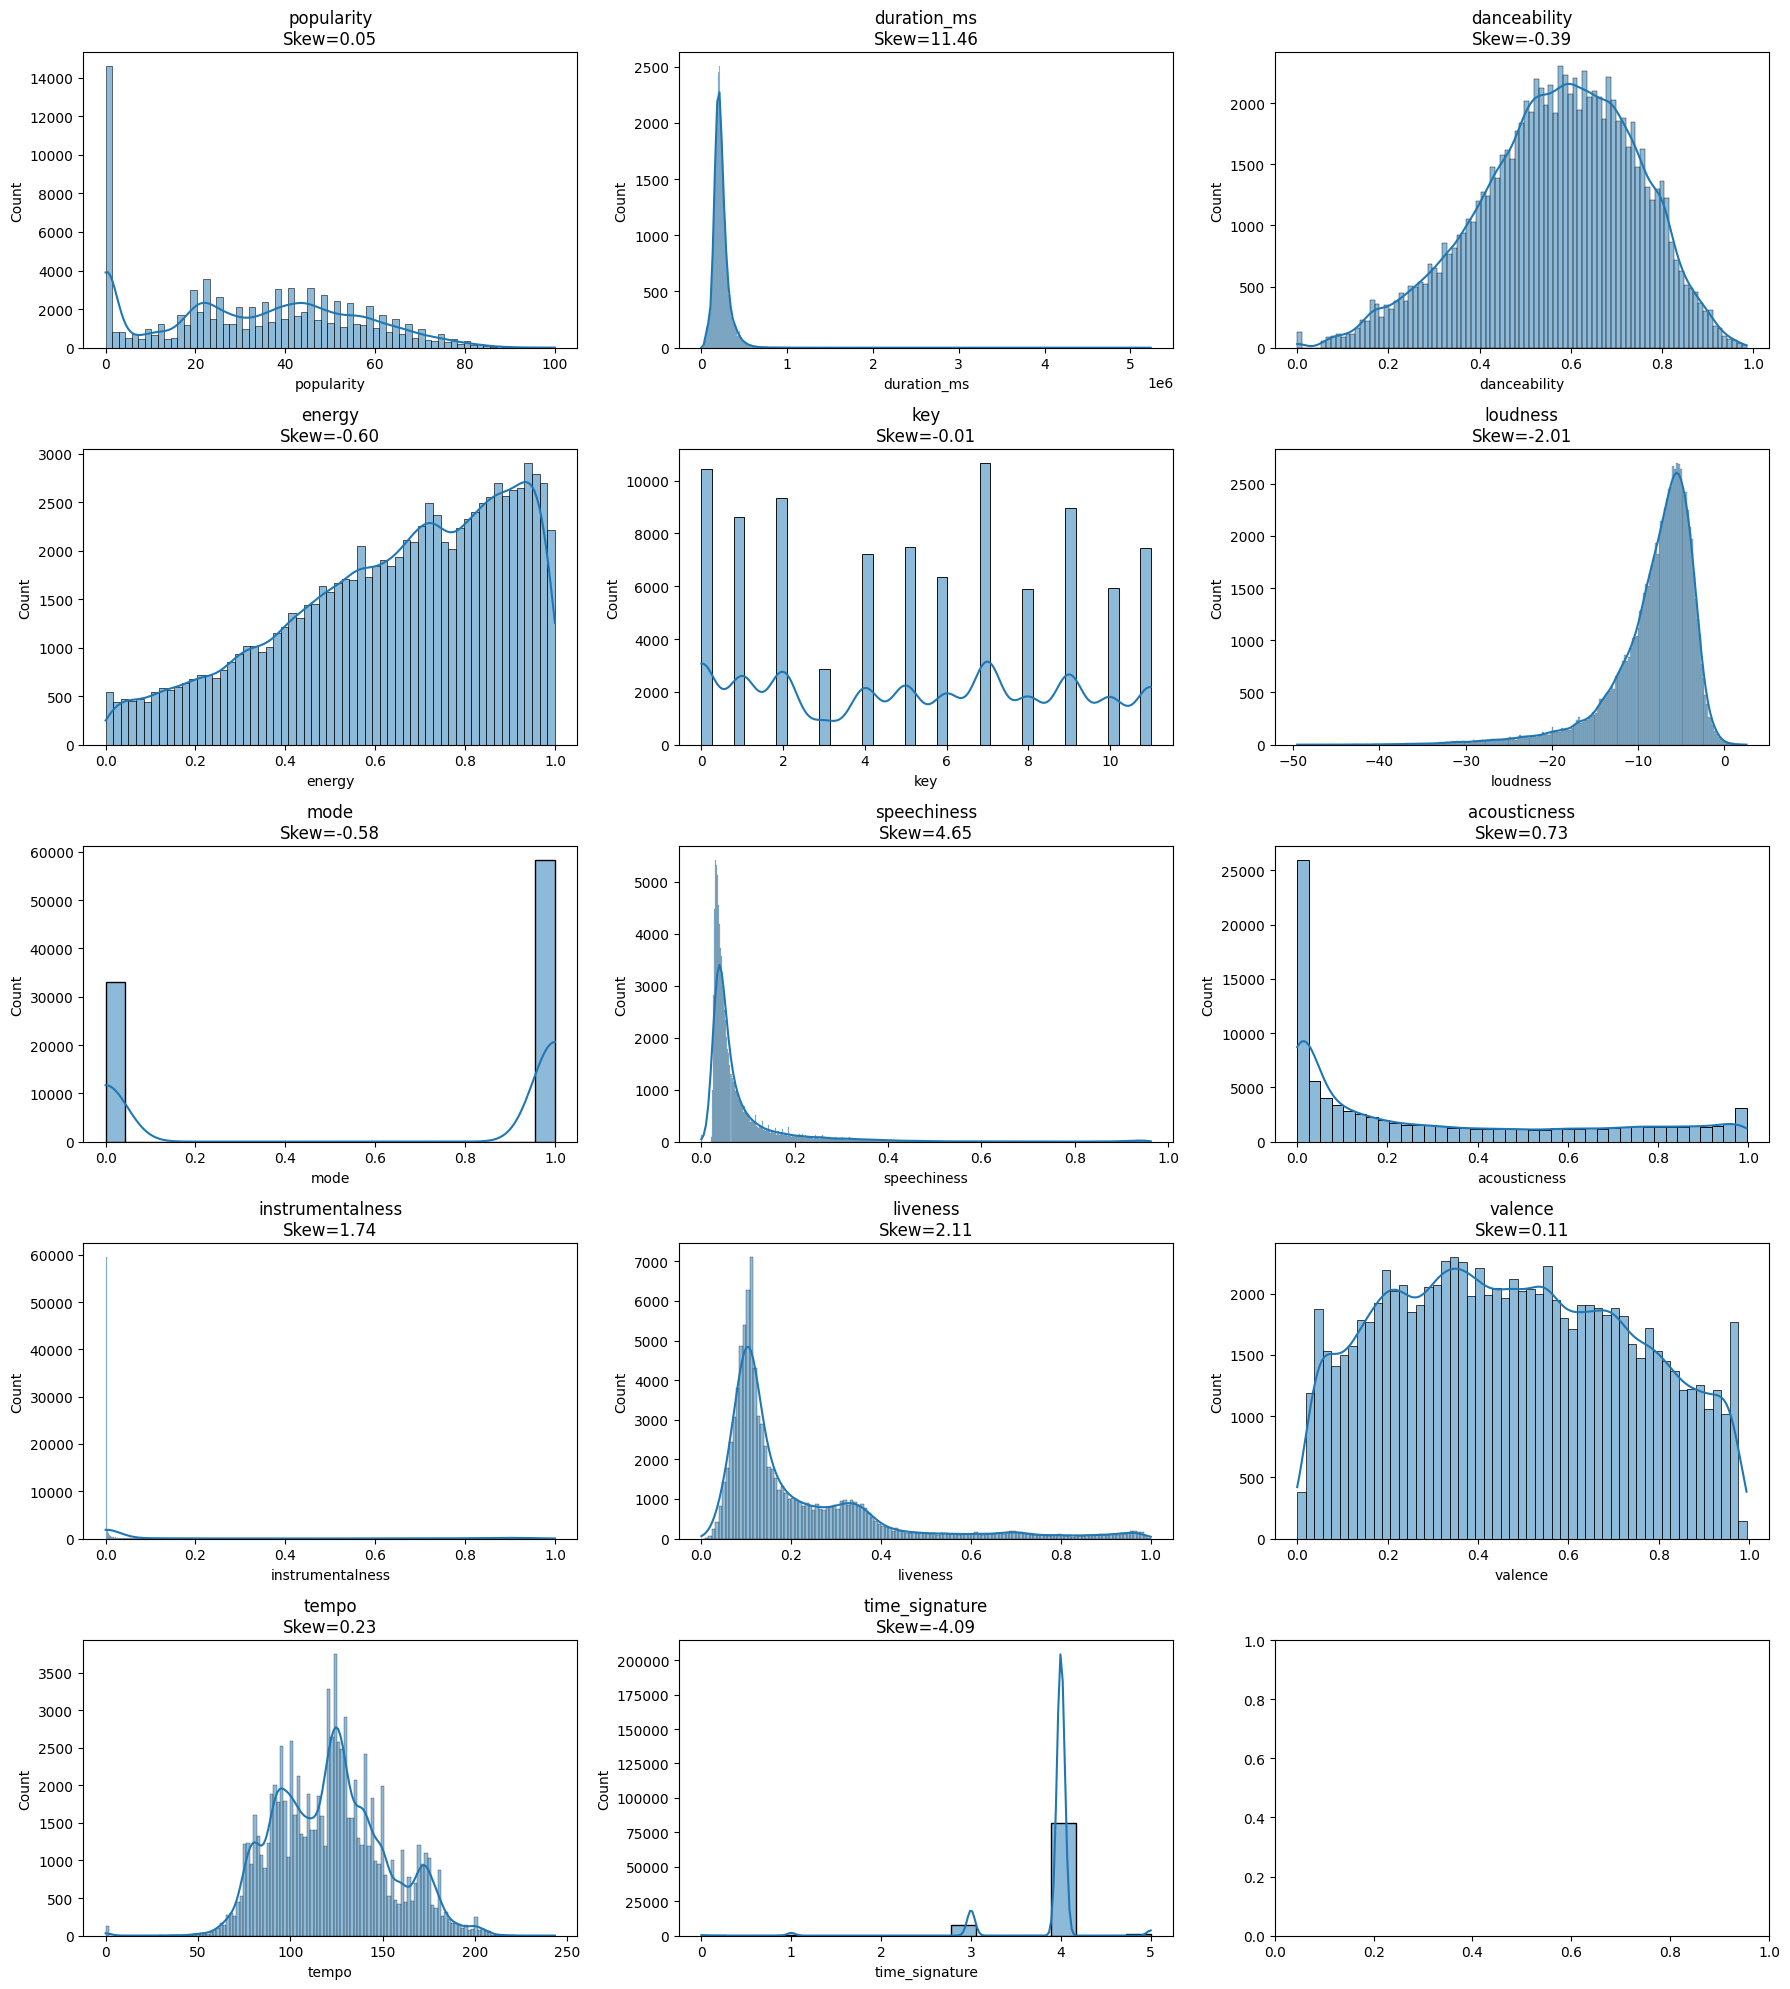

In [131]:
num_cols = X_train.select_dtypes(
    include=['int64', 'float64']
).columns

fig, axes = plt.subplots(
    nrows=(len(num_cols)+2)//3,
    ncols=3,
    figsize=(18,20)
)

axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(
        X_train[col],
        kde=True,
        ax=axes[i]
    )

    skew = X_train[col].skew()

    axes[i].set_title(
        f'{col}\nSkew={skew:.2f}'
    )

plt.tight_layout()
plt.show()

In [132]:
# 2. Quantitative Outlier Detection (IQR Method)

outlier_summary = []

for col in num_cols:

    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_outliers = (
        (X_train[col] < lower) |
        (X_train[col] > upper)
    ).sum()

    outlier_summary.append([
        col,
        n_outliers,
        round(n_outliers/len(X_train)*100,2)
    ])

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=[
        'Feature',
        'Outlier_Count',
        'Outlier_%'
    ]
)

outlier_df.sort_values(
    'Outlier_%',
    ascending=False
)

,Feature,Outlier_Count,Outlier_%
9,instrumentalness,20187,22.13
7,speechiness,10608,11.63
13,time_signature,9715,10.65
10,liveness,6902,7.57
5,loudness,4981,5.46
1,duration_ms,4502,4.94
2,danceability,496,0.54
12,tempo,484,0.53
0,popularity,2,0.00
3,energy,0,0.00


In [133]:
# 3. Features with Significant Outliers

outlier_df[
    outlier_df['Outlier_%'] > 5
]

,Feature,Outlier_Count,Outlier_%
5,loudness,4981,5.46
7,speechiness,10608,11.63
9,instrumentalness,20187,22.13
10,liveness,6902,7.57
13,time_signature,9715,10.65


1. What to check?
2. Which features have outliers?
3. What percentage of observations are outliers?
4. Are they data errors or valid extreme values?
5. Should they be: kept, capped, transformed, or removed?

Do not remove outliers immediately.

First identify:

1. Are they genuine music characteristics?
2. Or are they impossible values/errors?

# Step 10: Bivariate Analysis — Numerical Features vs Target
❓ What are we doing?

We are checking how each numerical feature behaves across different target classes.

❓ Why are we doing this?

To determine whether a feature helps distinguish between classes and may therefore be useful for prediction.

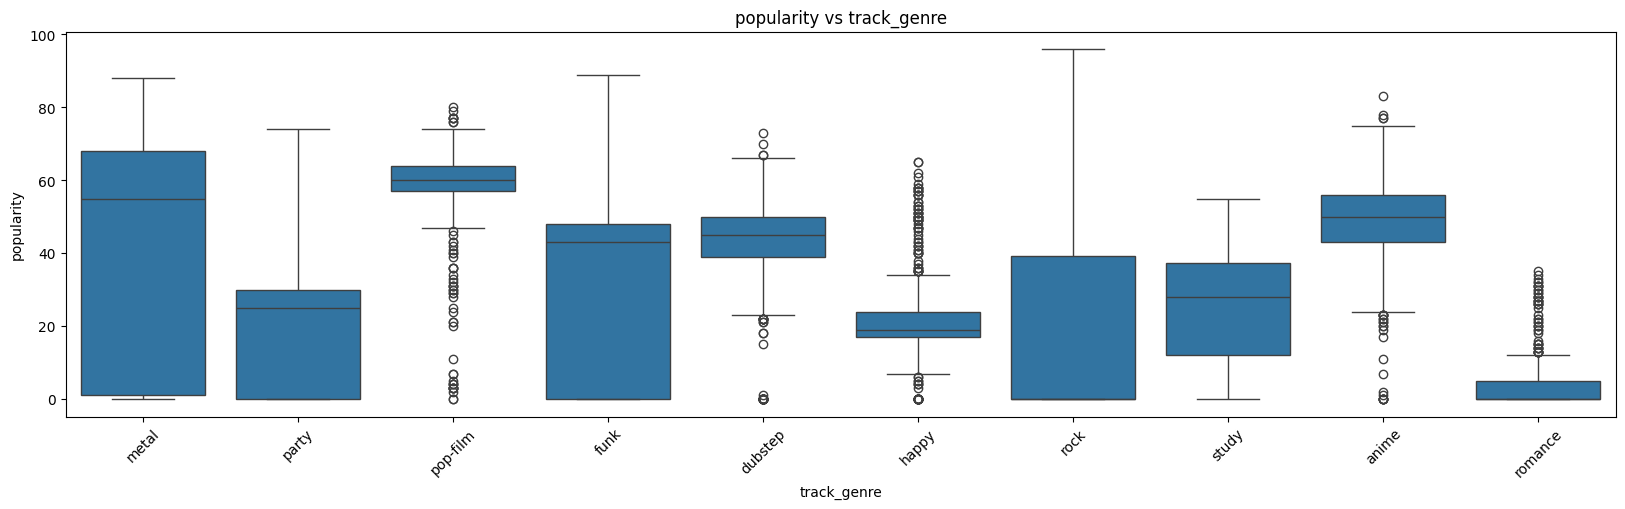

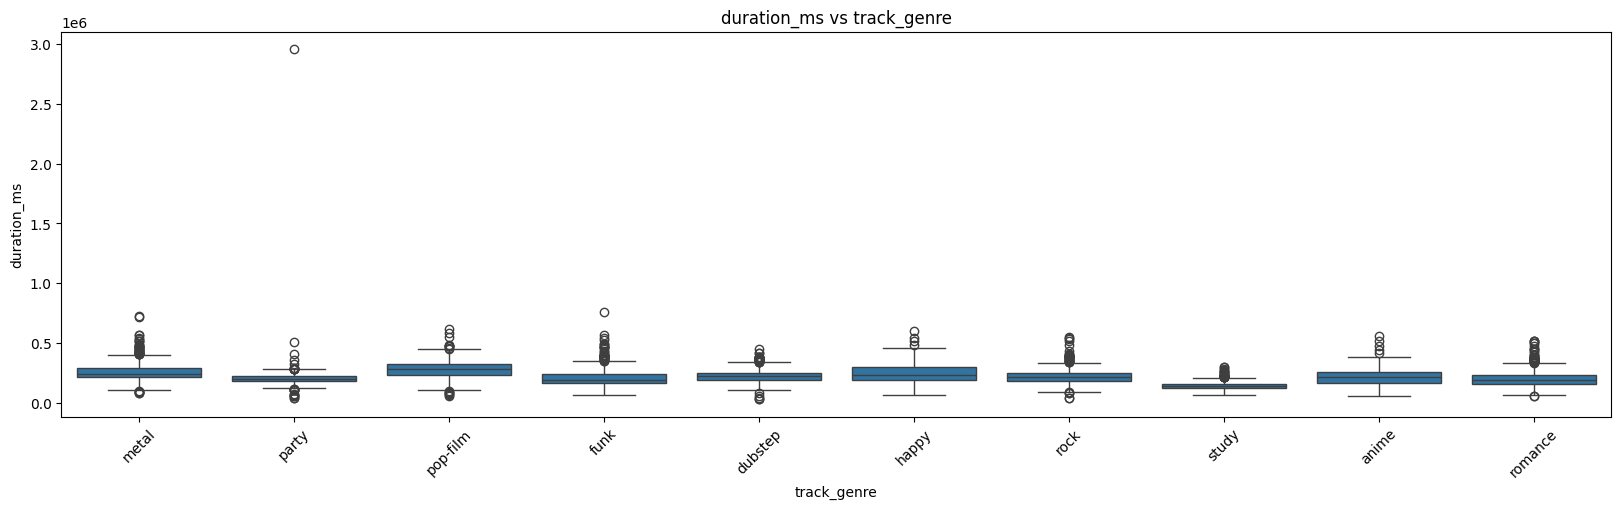

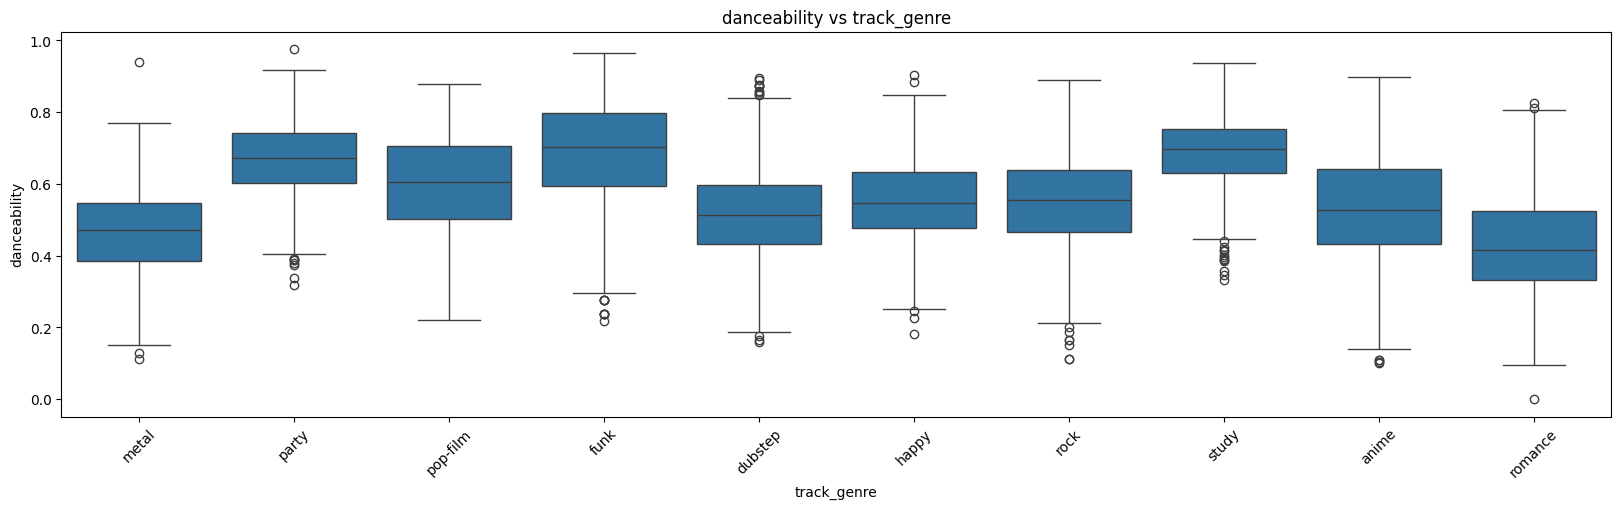

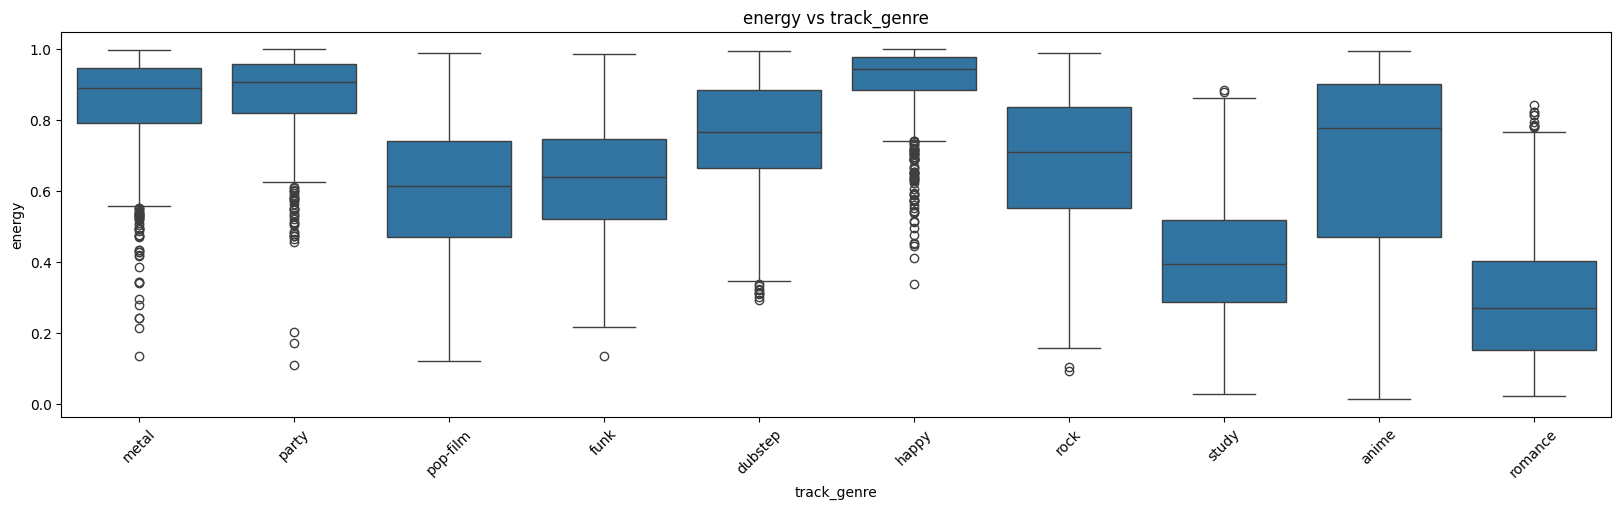

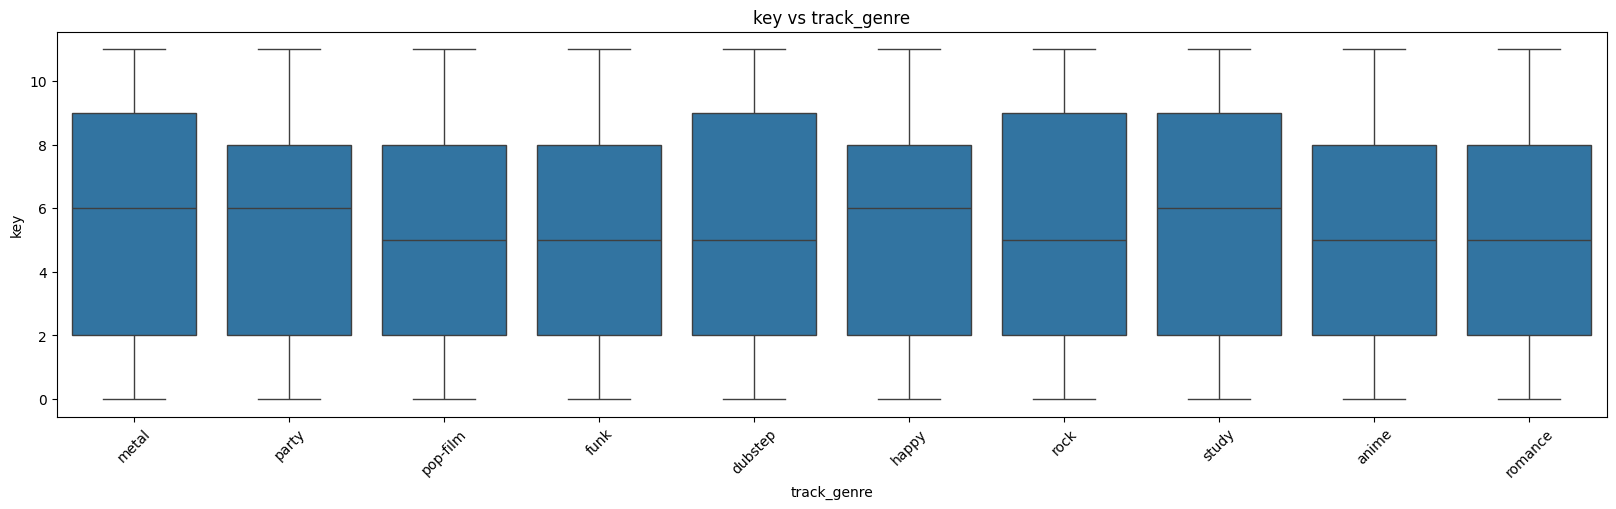

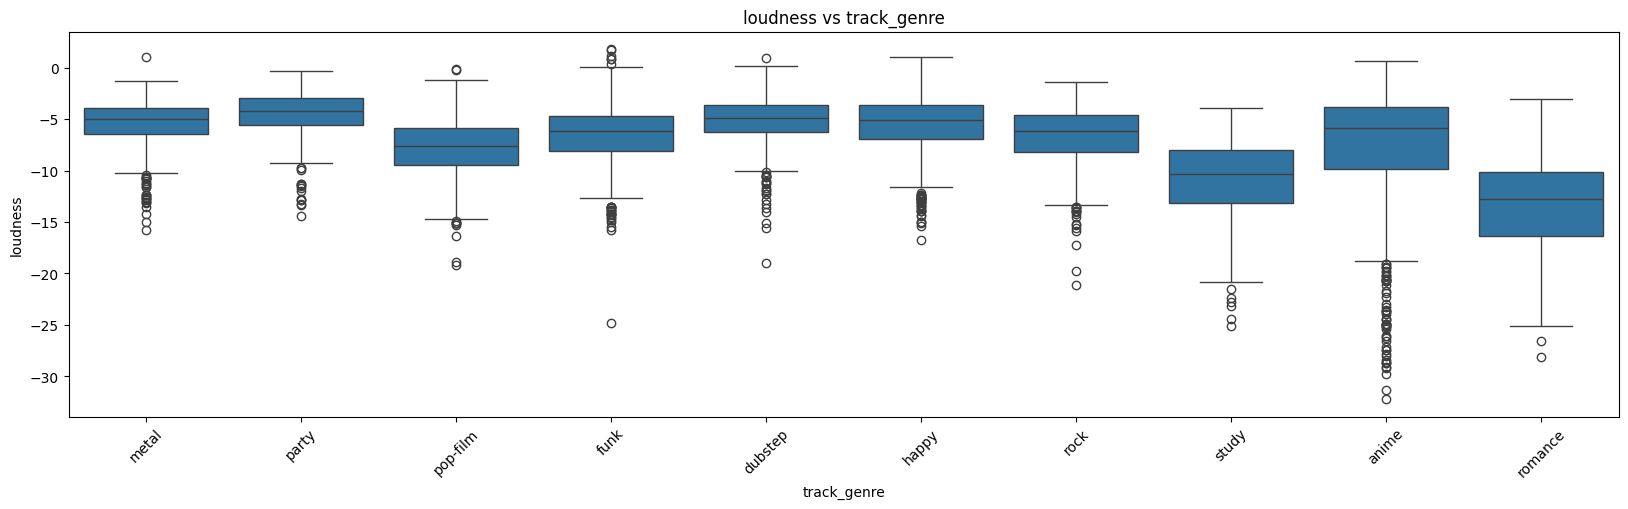

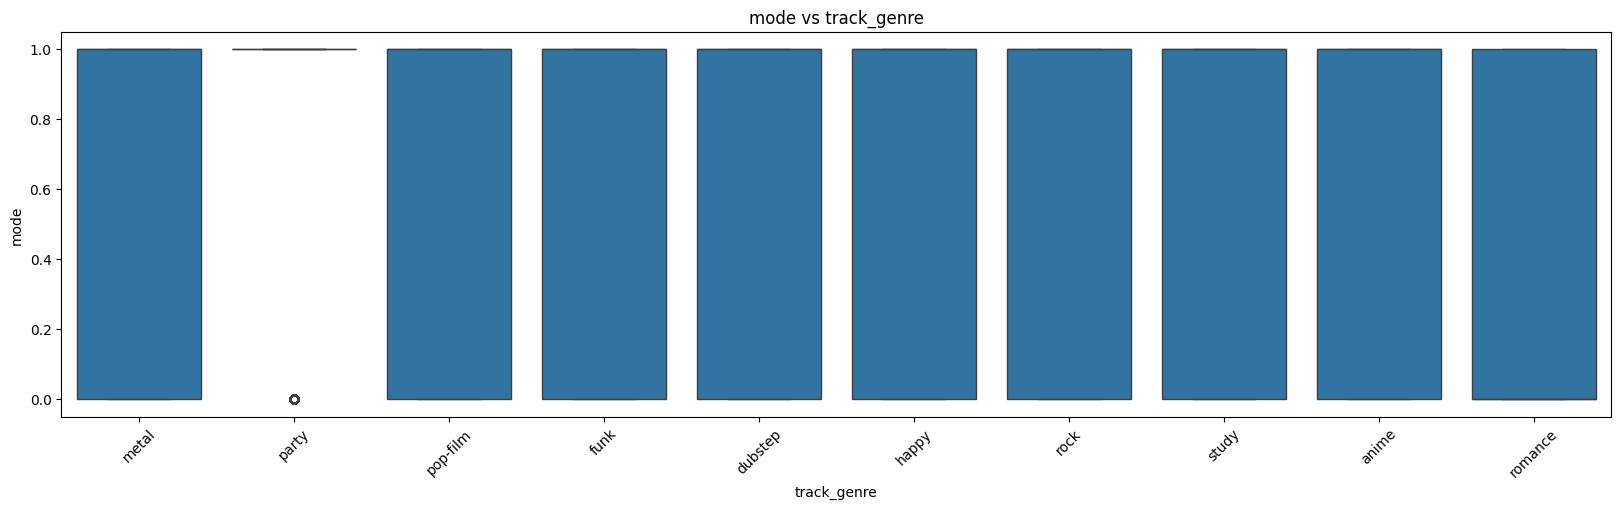

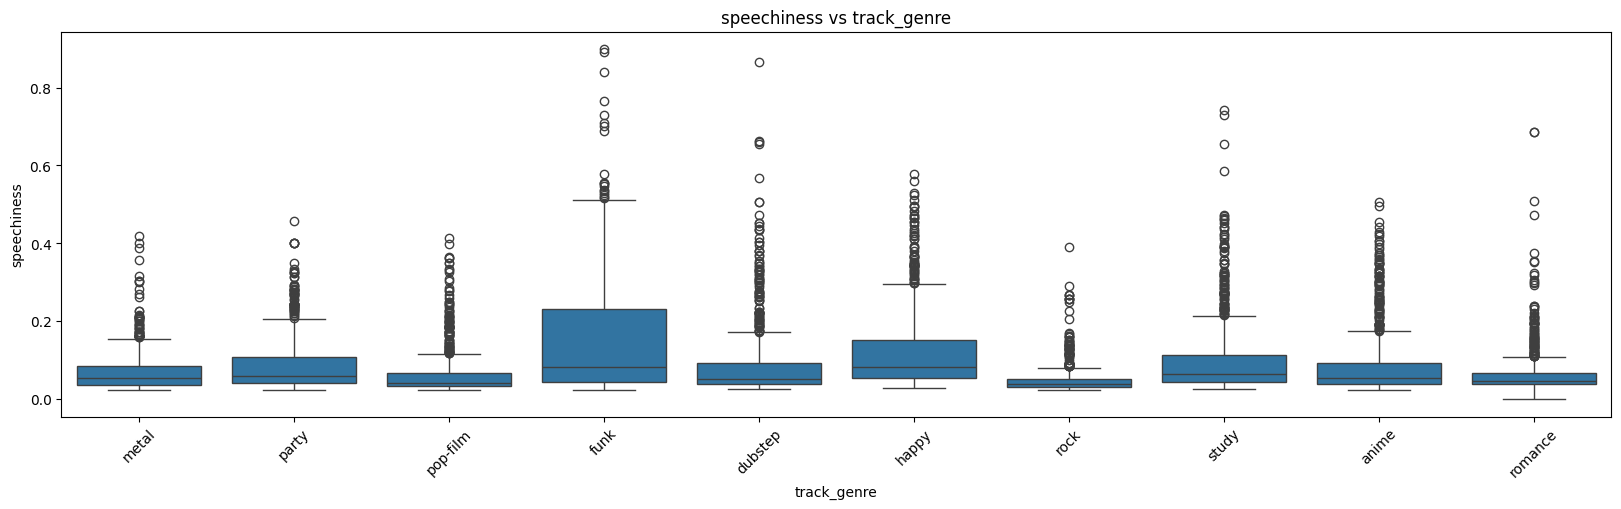

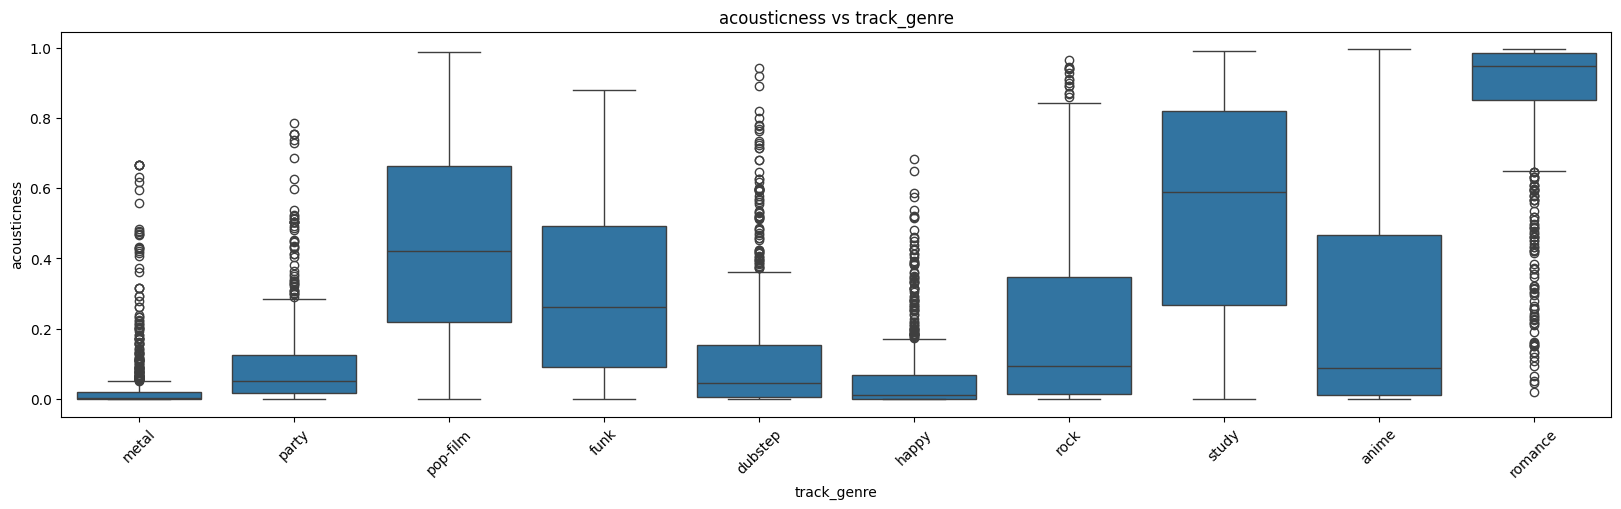

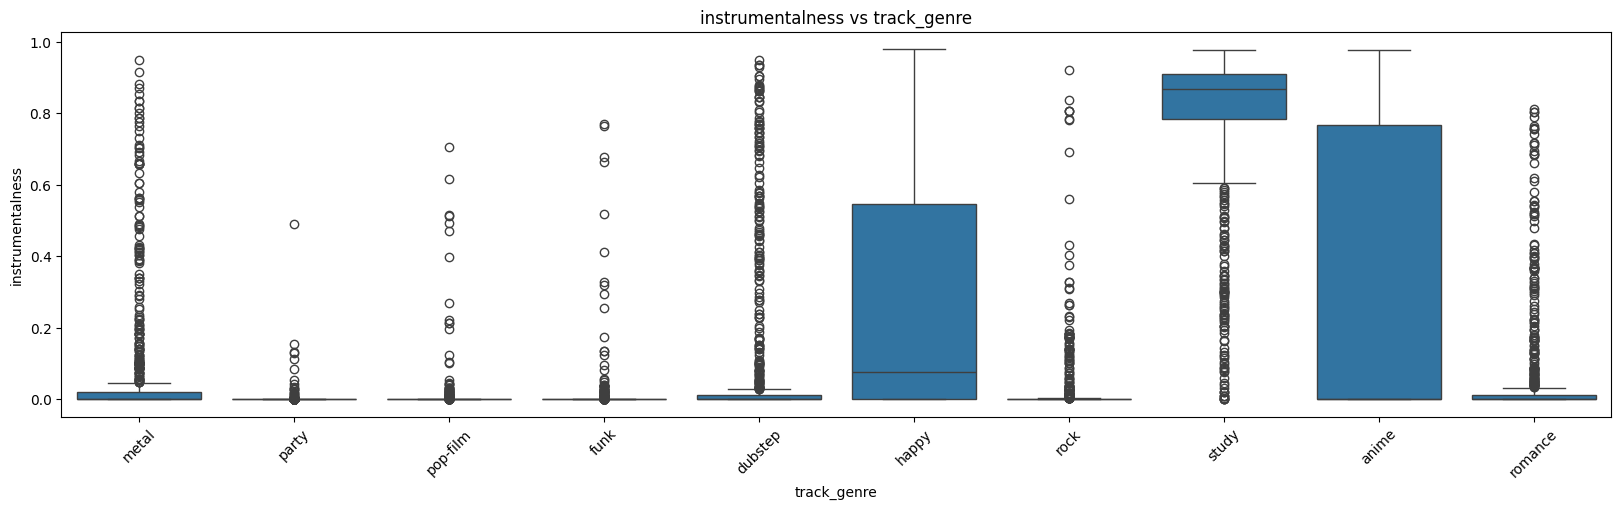

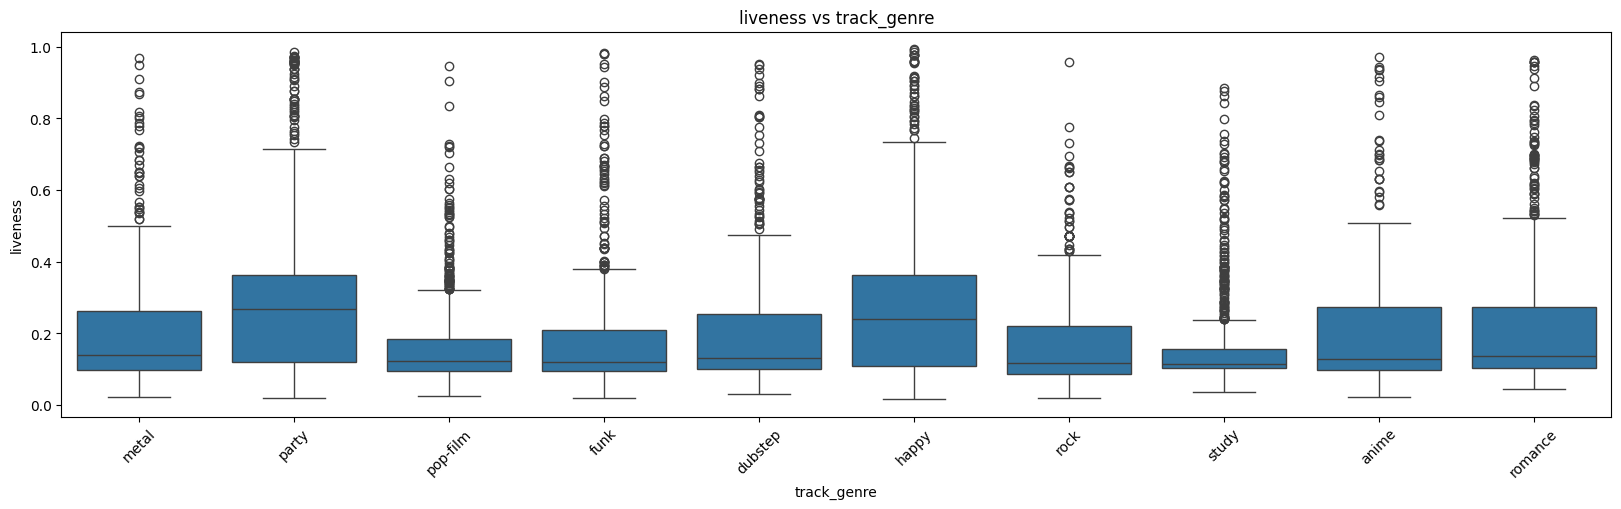

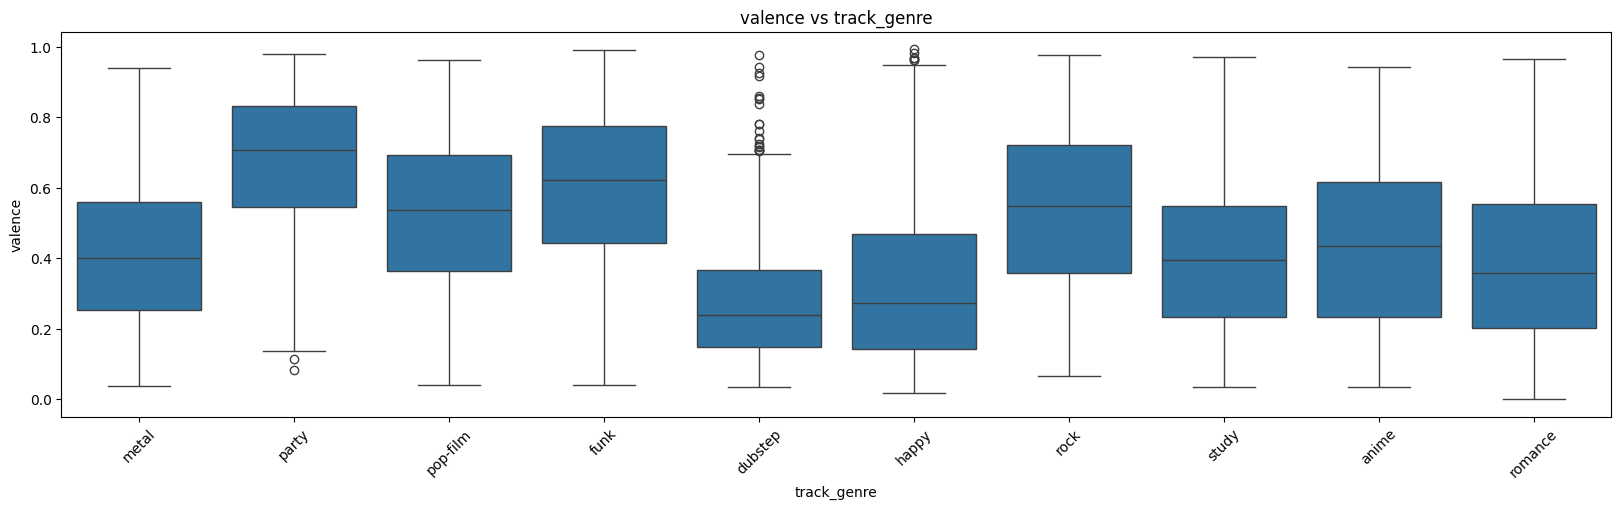

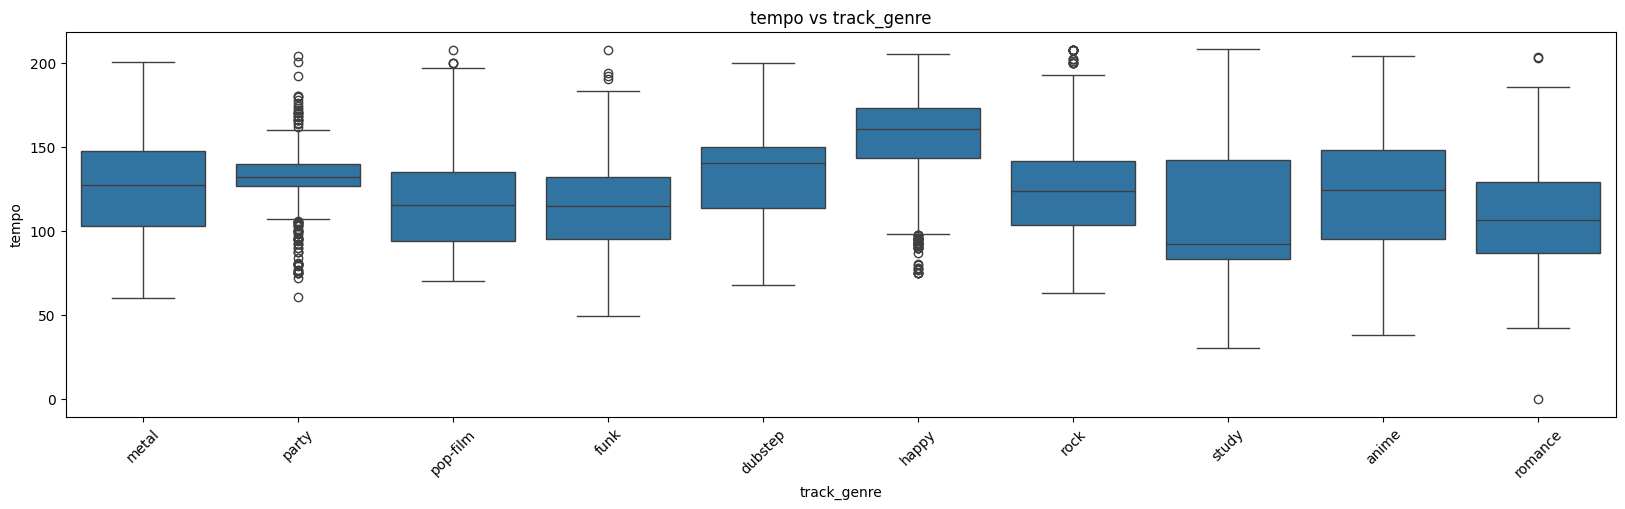

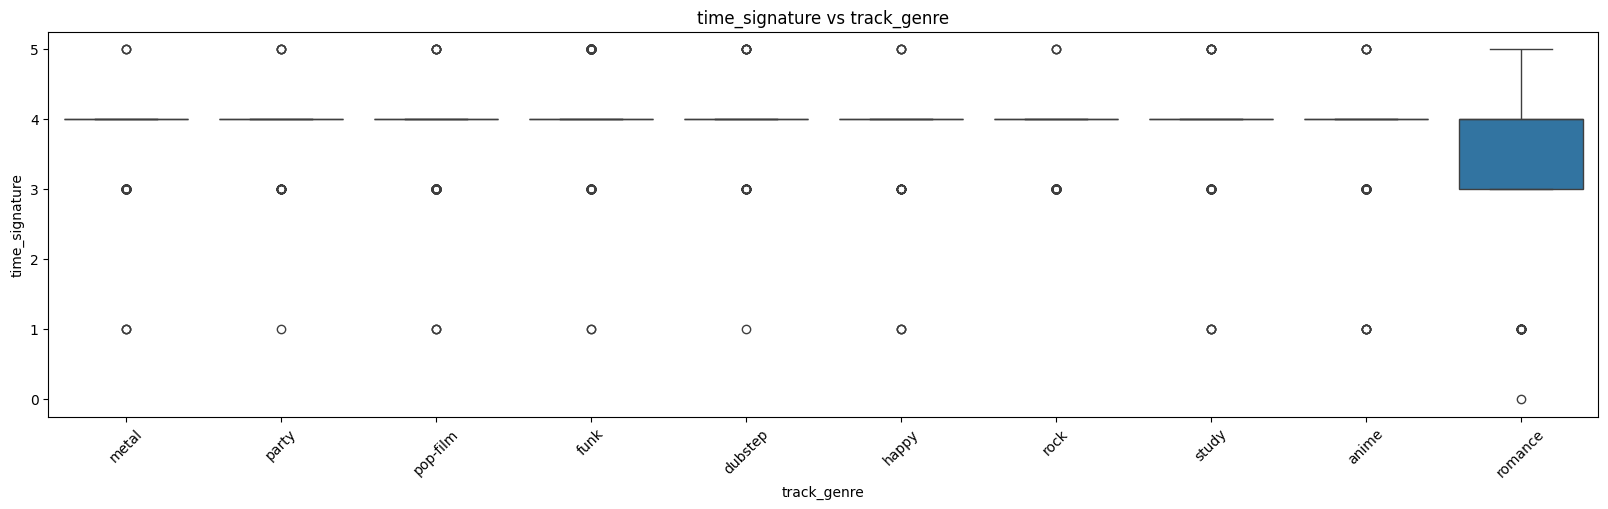

In [134]:
# Analyze the first 10 genres 
selected_genres = y_train.unique()[:10]

# Create temporary dataframe
temp = X_train.copy()
temp['track_genre'] = y_train

temp = temp[
    temp['track_genre'].isin(selected_genres)
]

# Numerical columns
num_cols = X_train.select_dtypes(
    include=['int64', 'float64']
).columns

# Boxplots
for col in num_cols:
    plt.figure(figsize=(20,5))

    sns.boxplot(
        x='track_genre',
        y=col,
        data=temp
    )

    plt.xticks(rotation=45)
    plt.title(f'{col} vs track_genre')

    plt.show()

What should you check?
1. Does the median differ across genres?
2. Do the distributions overlap heavily?
3. Which features separate genres well?
4. Which features appear uninformative?


Examples in this dataset:

5. danceability
6. energy
7. acousticness
8. instrumentalness
9. speechiness
10. valence

will likely show the strongest genre separation.

# Step 11: Bivariate Analysis — Categorical Features vs Target
❓ What are we doing?

We are analyzing the relationship between categorical features and the target variable.

❓ Why are we doing this?

To determine whether categorical variables contain predictive information for the target.

In [135]:
# selecting a subset of genres:
temp = X_train.copy()
temp['track_genre'] = y_train

temp = temp[
    temp['track_genre'].isin(selected_genres)
]

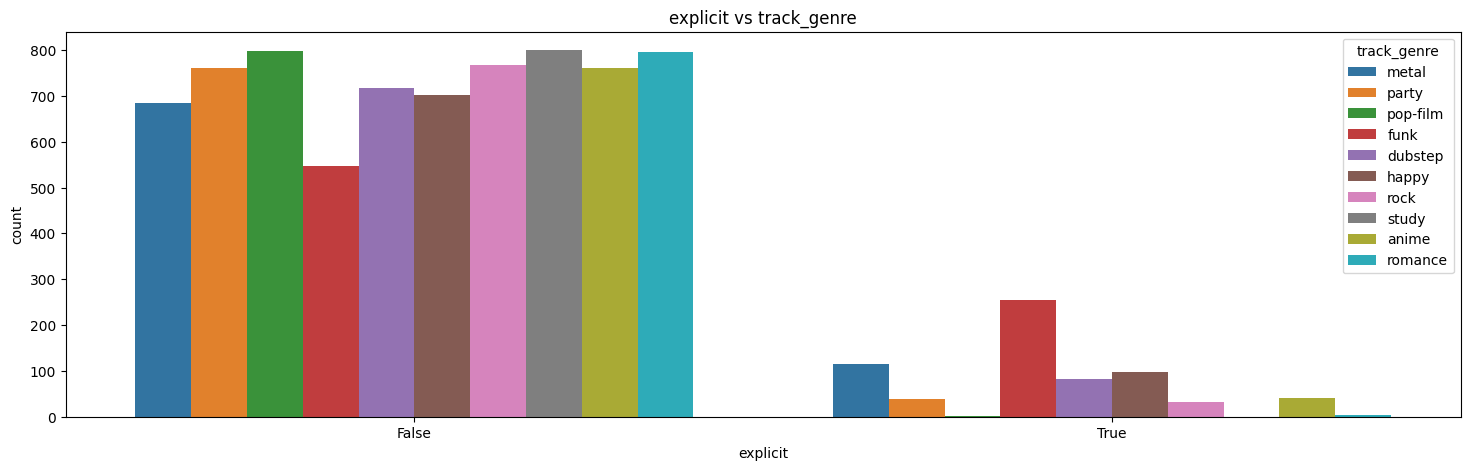

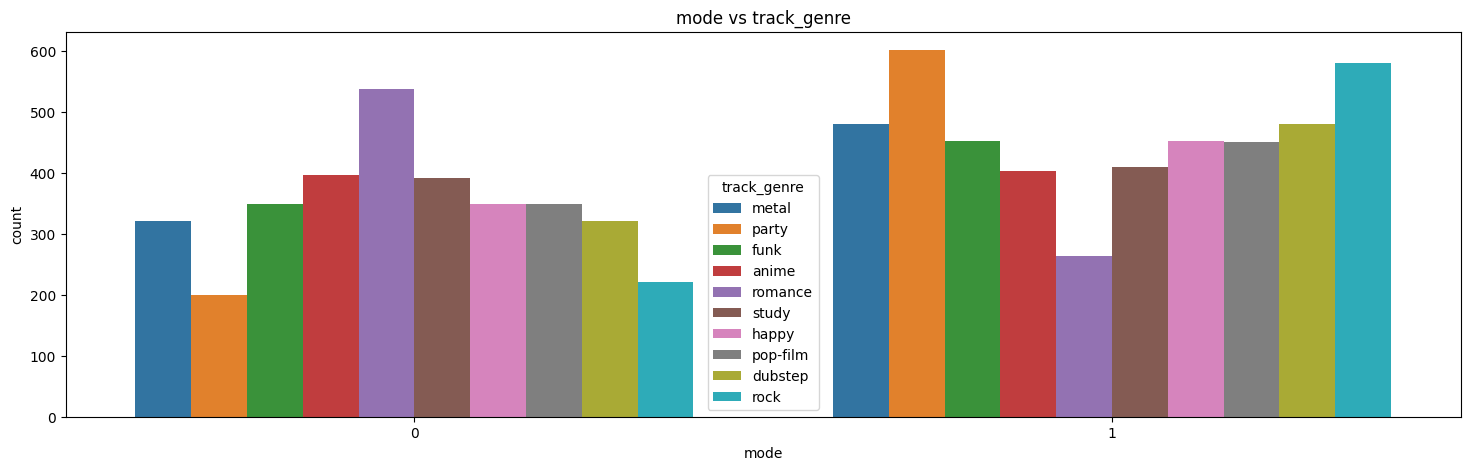

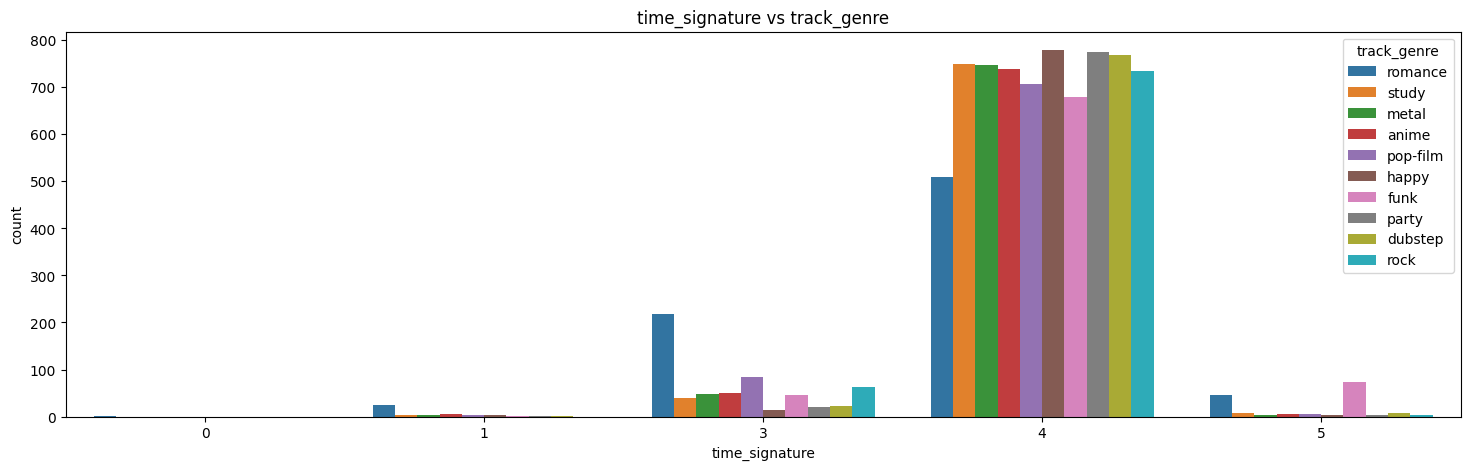

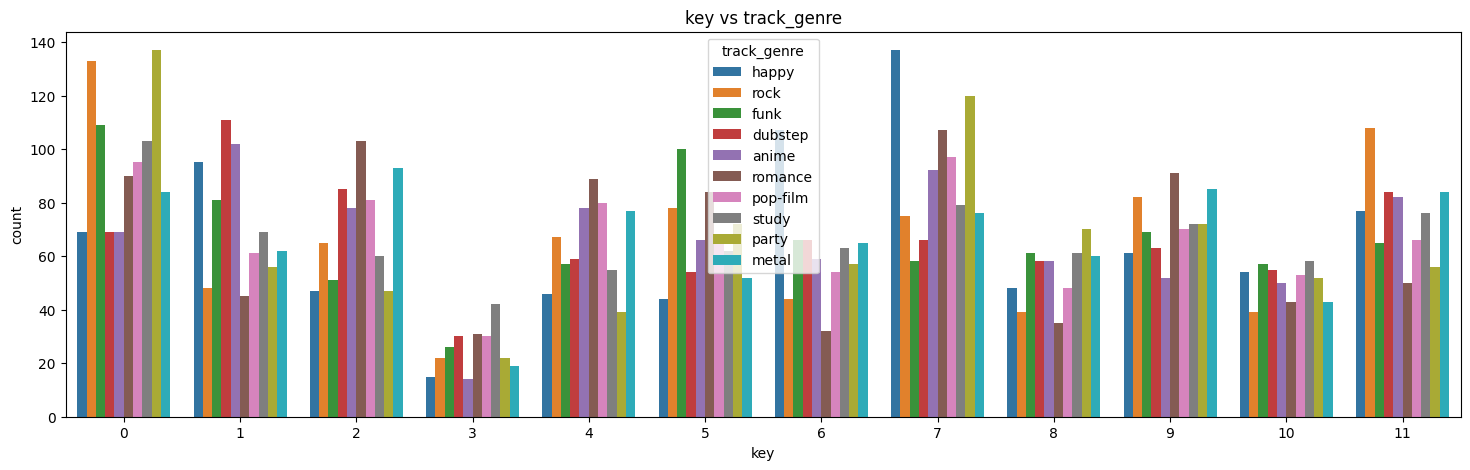

In [136]:
cat_cols = [
    'explicit',
    'mode',
    'time_signature',
    'key'
]

for col in cat_cols:

    plt.figure(figsize=(18,5))

    sns.countplot(
        data=temp,
        x=col,
        hue='track_genre'
    )

    plt.title(f'{col} vs track_genre')

    plt.show()

What should you check?

1. Does the distribution of categories change across genres?
2. Are some categories strongly associated with particular genres?
3. Does the feature appear to have predictive power?

Expected findings for this dataset:

| Feature          | Expected predictive power |
| ---------------- | ------------------------- |
| `explicit`       | Low to moderate           |
| `mode`           | Low                       |
| `time_signature` | Moderate                  |
| `key`            | Moderate                  |


Professional conclusion template:

Bivariate analysis of categorical features against the target variable was performed to assess their predictive relevance. The distributions of explicit, mode, time_signature, and key varied across music genres, suggesting that these variables may provide useful information for genre classification and will therefore be retained for subsequent modeling.

# Step 12: Correlation Analysis
❓ What are we doing?

We are measuring the relationship between numerical features.

❓ Why are we doing this?

To identify:

1. Redundant features
2. Multicollinearity
3. Features carrying almost the same information

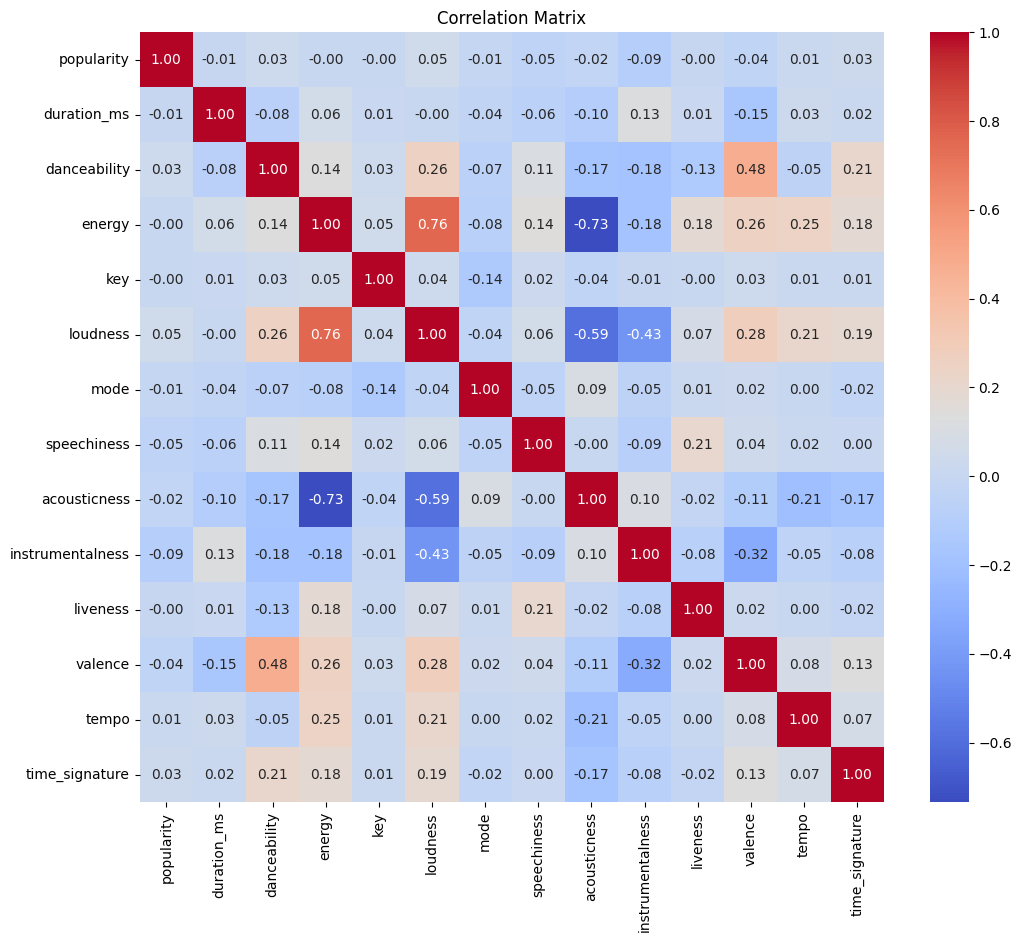

In [137]:
# Correlation Heatmap
corr = X_train[num_cols].corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.show()

In [138]:
# Find highly correlated pairs 
corr_matrix = X_train[num_cols].corr().abs()

upper = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

high_corr = [
    col
    for col in upper.columns
    if any(upper[col] > 0.80)
]

print(high_corr)

[]


What to check?
1. Correlation > 0.80
2. Correlation > 0.90
3. Features carrying nearly identical information

Professional decision rule 
| Correlation | Action                |
| ----------- | --------------------- |
| < 0.80      | Keep both             |
| 0.80–0.90   | Investigate           |
| > 0.90      | Consider removing one |


Important note for your Spotify project:

1. Correlation analysis applies only to numerical features.
2. High correlation is mainly problematic for linear models (Logistic Regression, Linear SVM).
3. For tree-based models (Random Forest, XGBoost, LightGBM), high correlation is usually less concerning

Final decision:
1. ✅ No highly correlated features found (r > 0.80)
2. ✅ No multicollinearity issue detected
3. ✅ Keep all numerical features

Correlation analysis was performed to identify redundant features and assess multicollinearity among numerical variables. No feature pairs exhibited a correlation coefficient greater than the predefined threshold of 0.80. This indicates that the numerical features do not suffer from significant multicollinearity, and therefore no features were removed based on correlation analysis.


# Step 13: Feature Importance Analysis , this will i do after preprocessing/encoding (OneHotEncoder, dropping text columns, etc.)
❓ What are we doing?

We are estimating how much each feature contributes to predicting the target variable.

❓ Why are we doing this?

To identify:

1. Important features
2. Weak or uninformative features
3. Potential features that can be removed later

In [139]:
# from sklearn.ensemble import RandomForestClassifier

# # Train a simple Random Forest
# rf = RandomForestClassifier(
#     n_estimators=100,
#     random_state=42,
#     n_jobs=-1
# )

# rf.fit(X_train_encoded, y_train)   # Use your encoded training data

# # Feature importance
# importance = pd.DataFrame({
#     'Feature': X_train_encoded.columns,
#     'Importance': rf.feature_importances_
# })

# importance = importance.sort_values(
#     'Importance',
#     ascending=False
# )

# print(importance.head(20))

In [140]:
# plt.figure(figsize=(10,6))

# plt.barh(
#     importance['Feature'][:20],
#     importance['Importance'][:20]
# )

# plt.gca().invert_yaxis()
# plt.title('Top 20 Feature Importances')

# plt.show()

# Step 13: Distribution Transformation Decision
❓ What are we doing?

We are deciding whether some numerical features should be transformed to reduce skewness and stabilize variance.

❓ Why are we doing this?

Because highly skewed features can negatively affect some machine learning algorithms (especially linear and distance-based models).

Use the results from:

1. ✅ Histograms + KDE
2. ✅ Skewness analysis
3. ✅ Boxplots
4. ✅ Kurtosis analysis

Decision rules
| Skewness    | Decision                   |
| ----------- | -------------------------- |
| -0.5 to 0.5 | No transformation          |
| 0.5 to 1    | Consider transformation    |
| > 1         | Transformation recommended |


Common transformations

| Situation                          | Transformation     |
| ---------------------------------- | ------------------ |
| Positive skew + no negative values | Log Transform      |
| Positive skew + positive values    | Box-Cox            |
| Positive/negative values           | Yeo-Johnson        |
| Extreme skew/outliers              | Quantile Transform |


In [141]:
skewness = X_train[num_cols].skew()

highly_skewed = skewness[
    abs(skewness) > 1
].sort_values(ascending=False)

print(highly_skewed)

duration_ms         11.460887
speechiness          4.645205
liveness             2.112556
instrumentalness     1.736409
loudness            -2.005550
time_signature      -4.093875
dtype: float64


Distribution analysis was performed using histograms, skewness statistics, kurtosis values, and boxplots to determine whether feature transformations were required. Features exhibiting substantial skewness will be considered for appropriate transformations such as logarithmic transformation, Yeo-Johnson transformation, or quantile transformation during the preprocessing stage. Features with approximately symmetric distributions will be retained without transformation.


At this step, you should only identify and document:

1. Which features need transformation
2. Which transformation method you plan to use

Then apply them later in your preprocessing pipeline.

# Step 14: Missing Value Treatment Strategy
❓ What are we doing?

We are documenting how missing values will be handled during preprocessing.

❓ Why are we doing this?

To ensure that missing data is handled systematically, reproducibly, and without introducing data leakage.

For your Spotify dataset:

You found only 3 missing values: 


| Column       | Missing Count | Decision |
| ------------ | ------------: | -------- |
| `artists`    |             1 | Drop     |
| `album_name` |             1 | Drop     |
| `track_name` |             1 | Drop     |


Since:

1. There are only 3 missing observations out of 114,000 rows (~0.003%),
2. Little's MCAR test indicated the data is not MCAR,
3. You have already decided to remove these observations,

there is no need for imputation.

Missing value analysis identified only three missing observations across the features `artists`, `album_name`, and `track_name`. Given the extremely small proportion of missing data relative to the dataset size, these observations will be removed during preprocessing rather than imputed. Consequently, no missing value imputation strategy is required for this project.


✅ Decision: Drop the 3 rows containing missing values; do not perform mode imputation.

# Step 15: Outlier Treatment Strategy
❓ What are we doing?

We are deciding how to handle the outliers identified during the outlier analysis step.

❓ Why are we doing this?

To reduce the impact of extreme values while preserving meaningful information.

For your Spotify dataset:

The outliers you found are mostly due to the natural characteristics of music tracks (e.g., very high tempo, very low acousticness, very high instrumentalness). These are valid observations, not data entry errors.

Since you are building a genre classification model, removing these observations could result in the loss of important genre-specific information.

Final decision:
1. ❌ Do not remove outliers.
2. ❌ Do not cap outliers.
3. ⚠️ Consider transformations later only if required by the chosen model.
4. ✅ Retain all outlier observations , means Keep all the outlier rows in the dataset. Do not delete, cap, or modify them

Outlier analysis revealed the presence of extreme values in several numerical features. However, these observations represent genuine variations in musical characteristics rather than data entry errors. Therefore, no outlier removal or capping will be performed to avoid losing potentially important genre-specific information. Outliers will be retained, and transformations may be considered later if required by specific machine learning algorithms.


# EDA FINAL SUMMARY 

The Spotify Tracks dataset contains 114,000 observations across 114 music genres, with each genre containing 1,000 tracks, resulting in a perfectly balanced multiclass classification problem.

During data quality assessment, three missing values were identified in the `artists`, `album_name`, and `track_name` features. Given the negligible proportion of missing data, these observations will be removed rather than imputed.

Duplicate analysis revealed that the `Unnamed: 0` column acted as a unique row identifier. After removing this identifier and excluding the target variable, a substantial number of duplicate feature vectors were identified. These duplicates represent legitimate observations with identical feature values and target labels. To avoid introducing bias and over-representation, duplicate records will be removed during preprocessing.

Cardinality analysis showed that `track_name`, `album_name`, and `artists` are high-cardinality categorical features. Due to their large number of unique values and limited suitability for classical machine learning models, these features will be excluded. The `track_id` feature was also removed as it serves only as a unique identifier.

Near-zero variance analysis and dominant category analysis indicated that all remaining features exhibit sufficient variability and provide potentially useful predictive information. Therefore, no additional features were removed based on these criteria.

Univariate analysis revealed that several numerical features exhibit skewed distributions and contain outliers. However, these extreme values represent genuine musical characteristics rather than data errors. Consequently, outliers will be retained, and feature transformations will be considered later if required by specific machine learning algorithms.

Target variable analysis confirmed that the dataset represents a balanced multiclass classification problem with no class imbalance issues.

Correlation analysis identified no strong multicollinearity among numerical features, with no correlation coefficients exceeding the predefined threshold of 0.80. Therefore, all numerical features will be retained.

Based on the exploratory analysis, the final preprocessing strategy will be:

* Remove `track_id`, `track_name`, `album_name`, and `artists`.
* Remove rows containing missing values.
* Remove duplicate observations.
* Retain all numerical audio features.
* Retain valid outliers.
* Keep `explicit` and `mode` as binary variables.
* Apply One-Hot Encoding to `time_signature` and `key`.
* Apply feature transformations only if required during model development.

The dataset is considered suitable for machine learning modeling after the planned preprocessing steps are applied.


In [142]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 91200 entries, 71066 to 8176
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   artists           91199 non-null  object 
 1   album_name        91199 non-null  object 
 2   track_name        91199 non-null  object 
 3   popularity        91200 non-null  int64  
 4   duration_ms       91200 non-null  int64  
 5   explicit          91200 non-null  bool   
 6   danceability      91200 non-null  float64
 7   energy            91200 non-null  float64
 8   key               91200 non-null  int64  
 9   loudness          91200 non-null  float64
 10  mode              91200 non-null  int64  
 11  speechiness       91200 non-null  float64
 12  acousticness      91200 non-null  float64
 13  instrumentalness  91200 non-null  float64
 14  liveness          91200 non-null  float64
 15  valence           91200 non-null  float64
 16  tempo             91200 non-null  float64


# Build the Preprocessing Pipeline

### Step 1: Define feature groups

In [143]:
drop_cols = [
    'track_name',
    'album_name',
    'artists'
]

binary_cols = [
    'explicit',
    'mode'
]

cat_cols = [
    'key',
    'time_signature'
]

num_cols = [
    'popularity',
    'duration_ms',
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo'
]

| Step                               | Action for Your Project                                       | Decision        |
| ---------------------------------- | ------------------------------------------------------------- | --------------- |
| **1. Define feature groups**       | Separate numerical, categorical, binary, dropped columns      | ✅ Do            |
| **2. Missing value handling**      | You decided to drop the 3 missing rows                        | ✅ Do            |
| **3. Rare category handling**      | Check whether `key` and `time_signature` have rare categories | ⚠️ Check        |
| **4. Categorical encoding**        | One-Hot Encode `key`, `time_signature`; keep binary columns   | ✅ Do            |
| **5. Feature scaling**             | Depends on model; for general pipeline, use `StandardScaler`  | ✅ Do            |
| **6. Distribution transformation** | Only if skewness > 1 and justified                            | ⚠️ Decide later |
| **7. Outlier treatment**           | Retain outliers                                               | ✅ No treatment  |
| **8. Feature engineering**         | No obvious feature engineering needed                         | ❌ Skip          |
| **9. Feature selection**           | Perform after encoding/modeling                               | ⚠️ Later        |
| **10. Multicollinearity removal**  | Already checked; no issue                                     | ✅ Done          |
| **11. Dimensionality reduction**   | Not needed                                                    | ❌ Skip          |
| **12. Build final pipeline**       | Build after all decisions are finalized                       | ✅ Final step    |


### Step 2: Missing Value Handling

In [144]:
# Check missing values
X_train.isnull().sum()

artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
dtype: int64

In [145]:
# Remove rows with missing values
train_mask = X_train.notna().all(axis=1)

X_train = X_train[train_mask]
y_train = y_train[train_mask]

Missing value analysis identified only three missing observations. Given the negligible proportion of missing data, these observations were removed rather than imputed. No further missing value treatment is required.

In [146]:
print(X_train.isnull().sum().sum())
print(y_train.shape)
print(X_train.shape)

0
(91199,)
(91199, 18)


### Step 3: Rare Category Handling